# Setup

In [1]:
from caveclient import CAVEclient
import numpy as np
import pandas as pd
from pathlib import Path
import glob
import os
import microns_datacleaner as mic
import microns_datacleaner.filters as fl
from scipy.ndimage import gaussian_filter
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import TwoSlopeNorm

In [2]:
# open dataset and set version
client = CAVEclient("minnie65_public")
client.materialize.version=1300

In [3]:
# a description of a specific table can be found this way
client.materialize.get_table_metadata('proofreading_status_and_strategy')

{'schema': 'compartment_proofread_status_strategy',
 'aligned_volume': 'minnie65_phase3',
 'created': '2024-06-03T19:46:04.824405',
 'table_name': 'proofreading_status_and_strategy',
 'id': 55554,
 'valid': True,
 'schema_type': 'compartment_proofread_status_strategy',
 'user_id': '4447',
 'description': 'The proofreading status of neurons that have been manually cleaned, extended, or both. Axon and dendrite compartment status are marked separately under status_axon and status_dendrite, as proofreading effort was applied differently to the different compartments in some cells. status_axon and status_dendrite are TRUE if the compartment is at least clean, meaning the synapses are accurate but possibly incomplete. strategy_axon and strategy_dendrite represent the specific strategy used for each compartment, the full details of which are available at www.microns-explorer.org/manifests/mm3-proofreading. Uploaded and maintained by Bethanny Danskin, with the help of Forrest Collman and and C

In [4]:
# Query tables

# Get list of neurons with extended proofreading of dendrites
dend_extended_df = client.materialize.query_table('proofreading_status_and_strategy',filter_in_dict={"strategy_dendrite": ["dendrite_extended"]})

# Coregistration table:   Between EM and 2P functional image
coregistration_manual_v4 = client.materialize.query_table('coregistration_manual_v4')

# nucleus_detection_v0: Table of each nucleus and their ID
nucleus_detection_v0= client.materialize.query_table('nucleus_detection_v0')
#nucleus_detection_v0.head()

# aibs_metamodel_celltypes_v661:    Cell type and layer
aibs_metamodel_celltypes_v661= client.materialize.query_table('aibs_metamodel_celltypes_v661')
#aibs_metamodel_celltypes_v661.head()

# neucleus_functional_area_assignment:      area [V1, LM, AL, RL]
nucleus_functional_area_assignment= client.materialize.query_table('nucleus_functional_area_assignment')
nucleus_functional_area_assignment.head()

# functional_properties_v3_bcm
functional_properties_v3_bcm = client.materialize.tables.functional_properties_v3_bcm().query()
# mask = functional_properties_v3_bcm['target_id'] == target_id_coreg
# functional_properties_v3_bcm[mask]

# Neuron selection

## Filter neurons from annotation tables

In [24]:
select_layer = "MC"  # 23P, 4P, 5P, etc
select_area = "V1"    # V1, LM, AL, RL
proof_status = False

# # 1) start set
# list_pt_root_id = coregistration_manual_v4[['pt_root_id']].drop_duplicates()

# 2) filter by layer
mask = aibs_metamodel_celltypes_v661['cell_type'] == select_layer
ids_23 = aibs_metamodel_celltypes_v661.loc[mask, 'pt_root_id'].drop_duplicates()
list_pt_root_id = list_pt_root_id[list_pt_root_id['pt_root_id'].isin(ids_23)]

# 3) filter by area
mask = nucleus_functional_area_assignment['tag'] == select_area
ids_v1 = nucleus_functional_area_assignment.loc[mask, 'pt_root_id'].drop_duplicates()
list_pt_root_id = list_pt_root_id[list_pt_root_id['pt_root_id'].isin(ids_v1)]

# 4) filter by dendrite proofreading ("dendrite_extended")
if proof_status == True:
    ids_dend_ext = (dend_extended_df['pt_root_id'].dropna().drop_duplicates())
    list_pt_root_id = list_pt_root_id[list_pt_root_id['pt_root_id'].isin(ids_dend_ext)]

## Grouping by gOSI

In [26]:
# Grouping neurons by gOSI: return list of neurons belong in certain gOSI threshold
def list_pt_root_id_gosi(list_pt_root_id, thr_low, thr_high):
    mask = (thr_low < functional_properties_v3_bcm['gOSI']) & (functional_properties_v3_bcm['gOSI'] <= thr_high)
    list_pt_root_id = pd.merge(list_pt_root_id['pt_root_id'], functional_properties_v3_bcm[mask]['pt_root_id'], how='inner', on=['pt_root_id'])
    
    list_uniq_root_id = list_pt_root_id.pt_root_id.unique()
    list_uniq_root_id = pd.DataFrame({'pt_root_id': list_uniq_root_id})
    
    return list_uniq_root_id

## Read from datacleaner

In [5]:
# Read from datacleaner
cleaner = mic.MicronsDataCleaner(datadir = "data", version=1300)   #Target version and download folder
cleaner.download_nucleus_data()    #Download the data
units, segments = cleaner.process_nucleus_data() #Process the downloaded data and segment into layers

Transform positions: 100%|████████████| 94014/94014 [00:00<00:00, 185147.26it/s]


## Read neurons

### Presaved Layers - Alessandro

#### Layer 23

In [19]:
# Bring automatched neurons from Alessandro Sanzeni
path_project = "/media/DATA1/CK/python_script/MicronsBinder_04/"
fname = "units_CW_layer23.csv"

neuron_list_23P = pd.read_csv(path_project + fname)
neuron_list_23P = neuron_list_23P["pt_root_id"].tolist()
print(len(neuron_list_23P))

7754


#### Layer 23 Automatch Alessandro

In [34]:
path_project = "/media/DATA1/CK/python_script/MicronsBinder_05/neuron_list_automatch/"
fname = "layer23_with_func.csv"

neuron_list_23_func = pd.read_csv(path_project + fname)
neuron_list_23P = neuron_list_23_func['post_pt_root_id'].unique().tolist()
print(len(neuron_list_23P))

3164


/tmp/ipykernel_932762/1422056120.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  neuron_list_23_func = pd.read_csv(path_project + fname)


#### Layer 4

In [20]:
# Bring automatched neurons from Alessandro Sanzeni
path_project = "/media/DATA1/CK/python_script/MicronsBinder_04/"
fname = "units_CW_layer4.csv"

neuron_list_4P = pd.read_csv(path_project + fname)
neuron_list_4P = neuron_list_4P["pt_root_id"].tolist()
print(len(neuron_list_4P))

5082


#### Layer 5

In [21]:
# Bring automatched neurons from Alessandro Sanzeni
path_project = "/media/DATA1/CK/python_script/MicronsBinder_04/"
fname = "units_CW_layer5.csv"

neuron_list_5P = pd.read_csv(path_project + fname)
neuron_list_5P = neuron_list_5P["pt_root_id"].tolist()
print(len(neuron_list_5P))

3321


### Presaved Layers - FINAL ME

In [10]:
# === Layer 23 ===
path_project = "/media/DATA1/CK/python_script/MicronsBinder_04/data/data_processed/"
path_layer23 = "neurons_23P_13305/"
fname = "full_features_all_L23_neurons.csv"

neuron_list_23P = pd.read_csv(path_project + path_layer23 + fname)

In [26]:
# === Layer 4 ===
path_project = "/media/DATA1/CK/python_script/MicronsBinder_04/data/data_processed/"
path_layer4 = "neurons_4P_9940/"
fname = "full_features_all_L4_neurons.csv"

neuron_list_4P = pd.read_csv(path_project + path_layer4 + fname)

In [35]:
# === Layer 5 ===
path_project = "/media/DATA1/CK/python_script/MicronsBinder_04/data/data_processed/"
path_layer5 = "neurons_5P_7148/"
fname = "full_features_all_L5_neurons.csv"

neuron_list_5P = pd.read_csv(path_project + path_layer5 + fname)

### Read from microns-datacleaner

#### Layer 4

In [11]:
# From datacleaner, bring excitatory neurons from 4 layer in V1
units_4P = fl.filter_neurons(units, cell_type=["4P"], brain_area=["V1"])
len(units_4P)

9940

#### Layer 5

In [12]:
# From datacleaner, bring excitatory neurons from 5 layer in V1
units_5P = fl.filter_neurons(units, cell_type=["5P-ET", "5P-IT", "5P-NP"], brain_area=["V1"])
len(units_5P)

7148

# Plot synapses

## Functions

In [13]:
# == Helper functions ==

# Function for dataframe to voxel position real world
def convert_to_nm(col, voxel_size=[4,4,40]):
    return np.vstack(col.values)*voxel_size

# Function for standard transformation (voxel → nm → standard/microns)
def convert_std(col, voxel_size=(4, 4, 40)):
    nm = convert_to_nm(col, voxel_size)
    return np.asarray(minnie_ds.transform_nm.apply(nm), dtype=float)
    
# Orientation difference between pre-post synapse
def orientation_to_colour(syn_pref_ori, neuron_pref_ori):
    # Normalize the orientations from [0, π] to [0, 1]
    syn_pref_ori_normalized = syn_pref_ori / np.pi
    neuron_pref_ori_normalized = neuron_pref_ori / np.pi
    
    # Centering on the Post-Synaptic Neuron's preferred orientation
    relative_orientation = (syn_pref_ori_normalized - neuron_pref_ori_normalized) % 1.0
    
    colour = cm.hsv(relative_orientation)
  
    # Return RGB and no Alpha(transparency)
    return colour[:3]

# Gets directions between 0 and 2π radians
def direction_to_colour(syn_pref_dir, neuron_pref_dir):
    # Normalize the directions from [0, 2π] to [0, 1]
    syn_pref_dir_normalized = syn_pref_dir / (2 * np.pi)
    neuron_pref_dir_normalized = neuron_pref_dir / (2 * np.pi)
    
    # Centering on the Post-Synaptic Neuron's preferred direction
    relative_direction = (syn_pref_dir_normalized - neuron_pref_dir_normalized) % 1.0
    
    colour = cm.hsv(relative_direction)

    # Return RGB and no Alpha(transparency)
    return colour[:3]

### Density map functions: all synapses

In [14]:
# ============================================
# == avg_density_map_all_synapses =============
# ============================================
"""
    This function calculates density map for all synapses,
    returns smoothed histogram map and saves the plot.
    
    Input: neuron_list, gOSI thresholds (used for title and filename)
           save_opt - True/False
           output_dir
    Returns:
        smoothed_hist_all_synapses
        saves figure: averaged density map of all neurons across with gaussian smoothed
"""

def avg_density_map_all_synapses(neuron_list, thr_low, thr_high, save_opt, output_dir):
    path_project = "/media/DATA1/CK/python_script/MicronsBinder_04/data/data_raw/synapse/"
    
    # Initialize a variable to store the cumulative sum of the normalized histogram
    avg_hist = None
    
    # Number of neurons
    num_neurons = len(neuron_list)
    
    for neuron_num in neuron_list:
        #print(f"Processing neuron # = {neuron_num}")
    
        # Read synapses
        fname = f"{neuron_num}_pre_synapse_df.pkl"
        pre_synapse_df = pd.read_pickle(path_project + fname)
    
        # Bring soma location
        mask = nucleus_detection_v0['pt_root_id'] == neuron_num
        soma_pos = convert_to_nm(nucleus_detection_v0[mask].pt_position)
        soma_pos_x = soma_pos[0, 0]
        soma_pos_y = soma_pos[0, 1]
        soma_pos_z = soma_pos[0, 2]
    
        # Add new columns with real-world scaled positions
        pre_synapse_df['ctr_pt_position_real'] = list(
            convert_to_nm(pre_synapse_df['ctr_pt_position'], voxel_size=[4, 4, 40]))
    
        # covert this to positions relative to soma (we want soma to be at the center)
        pre_synapse_df['ctr_pt_position_somarel'] = pre_synapse_df['ctr_pt_position_real'].apply(
            lambda pos: [pos[0] - soma_pos_x, pos[1] - soma_pos_y, pos[2] - soma_pos_z])
    
        # Take soma relative positions and scale to microns
        positions = np.vstack(pre_synapse_df['ctr_pt_position_somarel'])
        x_positions = positions[:, 0] / 1000
        y_positions = positions[:, 1] / 1000
    
        # Histogram
        bin_size = 10   # 10 microns per bin
        x_bins = np.arange(-200, 201, bin_size) # Set x range from -200 to 200 microns
        y_bins = np.arange(-600, 201, bin_size) # Set y range from -200 to 600 microns
        
        hist, x_edges, y_edges = np.histogram2d(x_positions, y_positions, bins=[x_bins, y_bins])
    
        # Normalize by the total number of synapses
        hist_normalized = hist / len(pre_synapse_df)
        
        # Normalize by the total number of synapses
        if avg_hist is None:
            avg_hist = hist_normalized
        else:
            avg_hist += hist_normalized
    
    # Calculate the average histogram (density map)
    avg_hist /= num_neurons
    avg_hist_all_synapses = avg_hist
    
    # Apply a 2D Gaussian filter with std=1 bin
    smoothed_hist_all_synapses = gaussian_filter(avg_hist_all_synapses, sigma=1)

    # ========================
    # Plot the smoothed heatmap
    # ========================

    # Compute extents and ranges from edges
    x_min, x_max = x_edges[0], x_edges[-1]
    y_min, y_max = y_edges[0], y_edges[-1]
    x_range = x_max - x_min   # e.g., 400 µm
    y_range = y_max - y_min   # e.g., 800 µm

    # Figure & axes sized to the data ratio (taller if y_range > x_range)
    figsize_base = 5  # scale this up/down to change overall size
    fig, ax = plt.subplots(figsize=(figsize_base, figsize_base * (y_range / x_range)))

    # Equal data scaling; no stretching
    im = ax.imshow(
        smoothed_hist_all_synapses.T,
        origin='lower',
        aspect='equal',  # one data unit in x == one data unit in y
        extent=[x_min, x_max, y_min, y_max],
        cmap='binary',
        vmin=0.0, vmax=0.01
    )

    # Match axes box to data ratio (requires matplotlib >= 3.3; safe to comment out if older)
    try:
        ax.set_box_aspect(y_range / x_range)
    except Exception:
        pass

    # Editable fonts in SVG
    plt.rcParams['svg.fonttype'] = 'none'
    
    # Colorbar (narrower + closer to the axes)
    cbar = fig.colorbar(im, ax=ax, fraction=0.07, pad=0.07)  # width & gap
    cbar.set_label('Density', fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    
    # Title and labels
    ax.set_title(f"Smoothed Average Density Map; gOSI bin {thr_low}_{thr_high}",
                 fontsize=20, fontweight='bold')
    ax.set_xlabel('X Position (µm)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Y Position (µm)', fontsize=16, fontweight='bold')

    # Your preferred ticks and limits (keeping your inverted y visual)
    ax.set_xticks([-200, 0, 200])
    ax.set_yticks([200, 0, -600])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(200, -600)   # keep your original look (top=+200, bottom=-600)

    fig.tight_layout()

    # Save or show
    if save_opt:
        # PNG
        filename = f"smoothed_average_synapse_density_map_all_synapses_{thr_low}_{thr_high}.png"
        output_path_smoothed = os.path.join(output_dir, filename)
        plt.savefig(output_path_smoothed, dpi=300, format='png')

        # SVG
        filename = f"smoothed_average_synapse_density_map_all_synapses_{thr_low}_{thr_high}.svg"
        output_path_smoothed = os.path.join(output_dir, filename)
        plt.savefig(output_path_smoothed, dpi=300, format='svg') 
        
        plt.close()
    else:
        plt.show()

    # Return final smoothed histogram
    return smoothed_hist_all_synapses

In [15]:
def avg_density_map_control_synapses(neuron_list, select_layer, save_opt, output_dir):
    """
    Average density map of presynaptic inputs filtered by layer (e.g., '4P', '5P', ...).
    Expects:
      - pre_synapse_df pickles per neuron at path_project
      - global tables: aibs_metamodel_celltypes_v661, nucleus_detection_v0
      - helper: convert_to_nm
    """
    path_project = "/media/DATA1/CK/python_script/MicronsBinder_04/data/data_raw/synapse/"

    avg_hist = None
    valid_count = 0
    total_selected_all = 0
    total_pre_all = 0

    for neuron_num in neuron_list:
        # --- load per-neuron synapses ---
        fname = f"{neuron_num}_pre_synapse_df.pkl"
        pre_synapse_df = pd.read_pickle(path_project + fname)
        total_num_pre = len(pre_synapse_df)

        # --- attach AIBS cell types (collapse 5P-IT/ET/NP -> 5P) ---
        aibs_tmp = aibs_metamodel_celltypes_v661[['pt_root_id', 'cell_type']].copy()
        aibs_tmp['cell_type'] = aibs_tmp['cell_type'].astype(str)
        aibs_tmp['cell_type_base'] = aibs_tmp['cell_type'].str.replace(r'-.*$', '', regex=True)
        ambiguous_ids = (
            aibs_tmp.groupby('pt_root_id')['cell_type_base'].nunique()
            .pipe(lambda s: s[s > 1].index)
        )
        aibs_lookup = (
            aibs_tmp.loc[~aibs_tmp['pt_root_id'].isin(ambiguous_ids)]
            .drop_duplicates(subset='pt_root_id', keep='first')
        )
        pre_synapse_df = (
            pre_synapse_df
            .merge(aibs_lookup, how='left', left_on='pre_pt_root_id', right_on='pt_root_id')
            .drop(columns=['pt_root_id'])
        )

        # --- filter by selected layer (use collapsed label) ---
        pre_synapse_df = pre_synapse_df[pre_synapse_df['cell_type_base'] == select_layer].copy()
        if pre_synapse_df.empty:
            print(f"[skip] Neuron {neuron_num}: no inputs for '{select_layer}'")
            continue

        valid_count += 1
        selected_num_pre = len(pre_synapse_df)
        total_selected_all += selected_num_pre
        total_pre_all += total_num_pre

        # --- soma position (nm) ---
        mask = nucleus_detection_v0['pt_root_id'] == neuron_num
        soma_pos = convert_to_nm(nucleus_detection_v0[mask].pt_position)
        sx, sy, sz = soma_pos[0, 0], soma_pos[0, 1], soma_pos[0, 2]

        # --- positions: nm -> real-world -> soma-relative -> microns ---
        pre_synapse_df['ctr_pt_position_real'] = list(
            convert_to_nm(pre_synapse_df['ctr_pt_position'], voxel_size=[4, 4, 40])
        )
        pre_synapse_df['ctr_pt_position_somarel'] = pre_synapse_df['ctr_pt_position_real'].apply(
            lambda p: [p[0] - sx, p[1] - sy, p[2] - sz]
        )
        positions = np.vstack(pre_synapse_df['ctr_pt_position_somarel'])
        x_positions = positions[:, 0] / 1000.0
        y_positions = positions[:, 1] / 1000.0

        # --- histogram ---
        bin_size = 10  # microns per bin
        x_bins = np.arange(-200, 201, bin_size)
        y_bins = np.arange(-600, 201, bin_size)
        hist, x_edges, y_edges = np.histogram2d(x_positions, y_positions, bins=[x_bins, y_bins])

        # --- per-neuron normalization and accumulate ---
        hist_normalized = hist / selected_num_pre
        if avg_hist is None:
            avg_hist = hist_normalized
        else:
            avg_hist += hist_normalized

    # --- nothing contributed ---
    if valid_count == 0:
        print(f"[end] No neurons had inputs for '{select_layer}'.")
        return None

    # --- average across contributing neurons ---
    avg_hist /= valid_count
    smoothed_hist_all_synapses = gaussian_filter(avg_hist, sigma=1)

    # --- plotting ---
    x_min, x_max = x_edges[0], x_edges[-1]
    y_min, y_max = y_edges[0], y_edges[-1]
    x_range = x_max - x_min
    y_range = y_max - y_min

    figsize_base = 5
    fig, ax = plt.subplots(figsize=(figsize_base, figsize_base * (y_range / x_range)))

    im = ax.imshow(
        smoothed_hist_all_synapses.T,
        origin='lower',
        aspect='equal',
        extent=[x_min, x_max, y_min, y_max],
        cmap='binary',
        vmin=0.0, vmax=0.01
    )

    try:
        ax.set_box_aspect(y_range / x_range)
    except Exception:
        pass

    plt.rcParams['svg.fonttype'] = 'none'

    cbar = fig.colorbar(im, ax=ax, fraction=0.07, pad=0.07)
    cbar.set_label('Density', fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    ax.set_title(f"Input from {select_layer} : {total_selected_all} / {total_pre_all}",
                 fontsize=20, fontweight='bold')
    ax.set_xlabel('X Position (µm)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Y Position (µm)', fontsize=16, fontweight='bold')

    ax.set_xticks([-200, 0, 200])
    ax.set_yticks([200, 0, -600])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(200, -600)

    fig.tight_layout()

    if save_opt:
        # PNG
        filename = f"{select_layer}_pre_filtered.png"
        output_path_smoothed = os.path.join(output_dir, filename)
        plt.savefig(output_path_smoothed, dpi=300, format='png')

        # SVG
        filename = f"{select_layer}_pre_filtered.svg"
        output_path_smoothed = os.path.join(output_dir, filename)
        plt.savefig(output_path_smoothed, dpi=300, format='svg') 
        
        plt.close()
    else:
        plt.show()

    return smoothed_hist_all_synapses


### Density map functions: functional synapses

In [16]:
# ==============================================
# ============= Functional synapses function ============
# ==============================================

def avg_density_map_func_synapses(neuron_list, thr_low, thr_high, save_opt, output_dir,
                                         include_zeros_in_denominator=False):
    """
    Average density map for FUNCTIONAL synapses (scaled plotting).

    include_zeros_in_denominator:
        False -> average over neurons that HAVE >=1 functional synapse (default).
        True  -> divide by total neurons provided (weights in zero-synapse neurons as 0).
    """
    
    path_project = "/media/DATA1/CK/python_script/MicronsBinder_04/data/data_raw/synapse/"

    # Bins shared across neurons
    bin_size = 10
    x_bins = np.arange(-200, 201, bin_size)   # -200 to 200 µm
    y_bins = np.arange(-600, 201, bin_size)   # -600 to 200 µm
    zero_hist = np.zeros((len(x_bins)-1, len(y_bins)-1), dtype=float)

    avg_hist = None
    contributed = 0
    x_edges = y_edges = None

    # Speed up membership test for "functional" presynaptic partners
    func_ids = set(functional_properties_v3_bcm['pt_root_id'].unique())

    for neuron_id in neuron_list:
        # Load synapses
        fname = os.path.join(path_project, f"{neuron_id}_pre_synapse_df.pkl")
        if not os.path.exists(fname):
            continue
        pre_synapse_df = pd.read_pickle(fname)
        if pre_synapse_df is None or len(pre_synapse_df) == 0:
            if include_zeros_in_denominator and avg_hist is None:
                avg_hist = zero_hist.copy()
            continue

        # Soma location
        soma_rows = nucleus_detection_v0[nucleus_detection_v0['pt_root_id'] == neuron_id]
        if soma_rows.empty:
            if include_zeros_in_denominator and avg_hist is None:
                avg_hist = zero_hist.copy()
            continue

        soma_nm = convert_to_nm(soma_rows.pt_position)
        soma_x, soma_y, soma_z = soma_nm[0, 0], soma_nm[0, 1], soma_nm[0, 2]

        # Positions (nm) -> soma-relative -> µm
        ctr_real = np.vstack(convert_to_nm(pre_synapse_df['ctr_pt_position'], voxel_size=[4, 4, 40]))
        rel = ctr_real - np.array([soma_x, soma_y, soma_z])
        x_um = rel[:, 0] / 1000.0
        y_um = rel[:, 1] / 1000.0

        # Filter to functional presynaptic partners
        func_mask = pre_synapse_df['pre_pt_root_id'].isin(func_ids)
        n_func = int(func_mask.sum())

        if n_func == 0:
            # No functional synapses for this neuron
            if include_zeros_in_denominator:
                if avg_hist is None:
                    # define edges at least once
                    _, x_edges, y_edges = np.histogram2d([0], [0], bins=[x_bins, y_bins])
                    avg_hist = zero_hist.copy()
            continue

        # Histogram for this neuron
        hist, x_edges_tmp, y_edges_tmp = np.histogram2d(x_um[func_mask], y_um[func_mask],
                                                        bins=[x_bins, y_bins])
        if x_edges is None:
            x_edges, y_edges = x_edges_tmp, y_edges_tmp

        # Normalize by functional synapse count for this neuron
        hist_norm = hist / n_func

        # Accumulate
        avg_hist = hist_norm if avg_hist is None else (avg_hist + hist_norm)
        contributed += 1

    # Decide denominator
    if include_zeros_in_denominator:
        denom = len(neuron_list)
    else:
        denom = contributed

    if denom == 0 or avg_hist is None:
        raise ValueError("No neurons contributed a functional-synapse histogram.")

    avg_hist /= denom
    smoothed_hist_func_synapses = gaussian_filter(avg_hist, sigma=1)

    # ========================
    # Scaled plotting (physical units, equal aspect)
    # ========================
    # Compute extents and ranges from edges
    x_min, x_max = x_edges[0], x_edges[-1]
    y_min, y_max = y_edges[0], y_edges[-1]
    x_range = x_max - x_min    # expected 400 µm
    y_range = y_max - y_min    # expected 800 µm

    # Figure & axes sized to the data ratio (taller if y_range > x_range)
    figsize_base = 5  # adjust global size via this scalar
    fig, ax = plt.subplots(figsize=(figsize_base, figsize_base * (y_range / x_range)))

    # Keep text editable in SVG
    plt.rcParams['svg.fonttype'] = 'none'

    # Equal data scaling; no stretching
    im = ax.imshow(
        smoothed_hist_func_synapses.T,
        origin='lower',
        aspect='equal',                      # 1 µm in X == 1 µm in Y
        extent=[x_min, x_max, y_min, y_max], # axes units are µm
        cmap='binary',
        vmin=0.0, vmax=0.01
    )

    # Match axes box to data ratio (Matplotlib ≥ 3.3)
    try:
        ax.set_box_aspect(y_range / x_range)
    except Exception:
        pass

    # Colorbar (narrow & close)
    cbar = fig.colorbar(im, ax=ax, fraction=0.07, pad=0.07)
    cbar.set_label('Density', fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    # Title clarifies denominator choice
    denom_tag = "per-neuron (contributors only)" if not include_zeros_in_denominator else "per-neuron (including zeros)"
    ax.set_title(f"Smoothed Avg Functional Density; gOSI {thr_low}-{thr_high} — {denom_tag}",
                 fontsize=20, fontweight='bold')
    ax.set_xlabel('X Position (µm)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Y Position (µm)', fontsize=16, fontweight='bold')

    # Ticks/limits (retain your inverted-Y visual)
    ax.set_xticks([-200, 0, 200])
    ax.set_yticks([200, 0, -600])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(200, -600)  # invert visually while keeping physical scaling

    fig.tight_layout()

    # Save or show
    if save_opt:
        os.makedirs(output_dir, exist_ok=True)

        # PNG
        fn = f"smoothed_average_synapse_density_map_func_synapses_{thr_low}_{thr_high}.png"
        plt.savefig(os.path.join(output_dir, fn), dpi=300, format='png')

        # SVG
        fn = f"smoothed_average_synapse_density_map_func_synapses_{thr_low}_{thr_high}.svg"
        plt.savefig(os.path.join(output_dir, fn), dpi=300, format='svg')

        plt.close(fig)
    else:
        plt.show()

    return smoothed_hist_func_synapses

### Density map difference function

In [17]:
# ==============================================
# ============= Difference function ============
# ==============================================

def density_diff(smoothed_func, smoothed_all, thr_low, thr_high, save_opt, output_dir):
    """
    Scaled difference map (functional - all synapses) with physical units and equal aspect.
    """
    # Difference
    avg_hist_diff = smoothed_func - smoothed_all

    # Symmetric color range around zero
    # vmax = np.nanmax(np.abs(avg_hist_diff))
    # vmin = -vmax
    vmin, vmax = -0.002, 0.002

    # Editable text in SVG
    plt.rcParams['svg.fonttype'] = 'none'

    # Bin edges (µm) matching the other plots
    bin_size = 10
    x_edges = np.arange(-200, 201, bin_size)  # [-200, 200]
    y_edges = np.arange(-600, 201, bin_size)  # [-600, 200]

    # Extents & aspect ratio from edges
    x_min, x_max = x_edges[0], x_edges[-1]
    y_min, y_max = y_edges[0], y_edges[-1]
    x_range = x_max - x_min   # 400 µm
    y_range = y_max - y_min   # 800 µm

    # Figure sized to data ratio (taller if y_range > x_range)
    figsize_base = 5
    fig, ax = plt.subplots(figsize=(figsize_base, figsize_base * (y_range / x_range)))

    # Plot with equal data scaling and physical extents
    im = ax.imshow(
        avg_hist_diff.T,
        origin='lower',
        aspect='equal',  # 1 µm in X == 1 µm in Y
        extent=[x_min, x_max, y_min, y_max],
        cmap='bwr',
        norm=TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    )

    # Match axes box to data ratio (Matplotlib ≥ 3.3)
    try:
        ax.set_box_aspect(y_range / x_range)
    except Exception:
        pass

    # Colorbar (narrower & close)
    cbar = fig.colorbar(im, ax=ax, fraction=0.07, pad=0.07)
    cbar.set_label('Density Difference (Func - All)', fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    # Title & labels
    ax.set_title(f'Difference Map: Func - All Synapses; gOSI {thr_low}-{thr_high}',
                 fontsize=20, fontweight='bold')
    ax.set_xlabel('X Position (µm)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Y Position (µm)', fontsize=16, fontweight='bold')

    # Ticks and limits (retain your inverted-Y visual)
    ax.set_xticks([-200, 0, 200])
    ax.set_yticks([200, 0, -600])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(200, -600)  # invert visually while keeping physical scaling

    fig.tight_layout()

    # Save or show
    if save_opt:
        os.makedirs(output_dir, exist_ok=True)

        # PNG
        fn = f"smoothed_difference_scaled_{thr_low}_{thr_high}.png"
        plt.savefig(os.path.join(output_dir, fn), dpi=300, format='png')

        # SVG
        fn = f"smoothed_difference_scaled_{thr_low}_{thr_high}.svg"
        plt.savefig(os.path.join(output_dir, fn), dpi=300, format='svg')
        
        plt.close(fig)
    else:
        plt.show()

    return avg_hist_diff


In [18]:
# ==============================================
# ============= Difference function with summed and AUC ============
# ==============================================

def plot_density_diff_with_auc(diff_matrix, post_layer, save_opt, output_dir):
    """
        Plot a density-difference heatmap with summed row profile and its AUC.
    
        Args:
            diff_matrix : 2D np.ndarray (40 x 80)
            post_layer  : str (e.g., "23P")
            save_opt    : bool  (False=show, True=save)
            output_dir  : str or Path
    
        Returns:
            auc_abs (float): area under |row_sums| curve (units: Δ-density * µm)
    """

    # --- data/params  ---
    vmax, vmin = 0.002, -0.002
    x_edges = np.arange(-200, 201, 10)
    y_edges = np.arange(-600, 201, 10)
    x_min, x_max = x_edges[0], x_edges[-1]
    y_min, y_max = y_edges[0], y_edges[-1]
    row_sums = np.sum(diff_matrix, axis=0)
    row_sums_abs = np.abs(row_sums)
    
    # calculate AUC (basically summing up all values by each bin size)
    bin_height  = np.diff(y_edges)            # all 10 µm here
    auc_abs = np.sum(row_sums_abs * bin_height)
    
    # saves texts editable
    plt.rcParams['svg.fonttype'] = 'none'
    
    # --- figure & axes with matched heights ---
    fig, ax0 = plt.subplots(figsize=(6, 8))
    divider = make_axes_locatable(ax0)
    ax1 = divider.append_axes("right", size="25%", pad=0.6, sharey=ax0)  # profile axis (same height)
    cax = divider.append_axes("right", size="3%", pad=0.15)              # slim colorbar axis
    
    # --- heatmap ---
    im = ax0.imshow(
        diff_matrix.T,
        origin="lower",
        extent=[x_min, x_max, y_min, y_max],
        cmap="bwr",
        norm=TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax),
        aspect="equal",
    )
    # keep true 1:2 µm aspect
    ax0.set_box_aspect((y_max - y_min) / (x_max - x_min))  # == 2.0
    
    ax0.set_title("Difference Map: Func - All Synapses", fontsize=14, fontweight="bold")
    ax0.set_xlabel("X Position (µm)", fontsize=12, fontweight="bold")
    ax0.set_ylabel("Y Position (µm)", fontsize=12, fontweight="bold")
    ax0.set_xticks([-200, 0, 200])
    ax0.set_yticks([200, 0, -600])
    ax0.set_xlim(x_min, x_max)
    ax0.set_ylim(200, -600)  # inverted visual
    
    # colorbar sized/aligned to heatmap
    cb = fig.colorbar(im, cax=cax)
    cb.set_label("Δ density", rotation=270, labelpad=14)
    
    # --- right profile (shares Y, identical height) ---
    ax1.plot(row_sums, y_edges[:-1], linewidth=2, color="grey")
    ax1.plot(row_sums_abs, y_edges[:-1], linewidth=2, color="red", alpha=0.8)
    ax1.axvline(0, color="grey", linestyle="--")
    ax1.set_xlabel(f"AUC {auc_abs:.2f}", fontsize=12, fontweight="bold")
    ax1.set_yticks([200, 0, -600])
    ax1.set_ylim(200, -600)
    ax1.yaxis.set_label_position("right")
    fig.tight_layout()

    # Save or show
    if save_opt:
        os.makedirs(output_dir, exist_ok=True)

        # PNG
        fn = f"{post_layer}_smoothed_difference_AUC_scaled.png"
        plt.savefig(os.path.join(output_dir, fn), dpi=300, format='png')

        # SVG
        fn = f"{post_layer}_smoothed_difference_AUC_scaled.svg"
        plt.savefig(os.path.join(output_dir, fn), dpi=300, format='svg')
        
        plt.close(fig)
    else:
        plt.show()

# Main

## BAD analysis classic

### 23P

In [49]:
# === 23L neurons ==
path_save = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"
path_save_data = 'media/DATA1/CK/python_script/MicronsBinder_05/BAD_matrix/"

# Calculate all synapses
smoothed_hist_all_synapses = avg_density_map_all_synapses(neuron_list_23P, 0, 1, True, path_save)

# Calculate functional synapses
smoothed_hist_func_synapses = avg_density_map_func_synapses(neuron_list_23P, 0, 1, True, path_save)

# Calculate differences
smoothed_diff = density_diff(smoothed_hist_func_synapses, smoothed_hist_all_synapses, 0, 1, True, path_save)


# Save matrix
fname = '23P_smoothed_average_synapse_density_map_all_synapses.npy'
fname_func = '23P_smoothed_average_synapse_density_map_func_synapses_0_1.npy'
fname_diff = '23P_smoothed_difference_scaled_0_1.npy'
np.save(path_save_data + fname, smoothed_hist_all_synapses)
np.save(path_save_data + fname_func, smoothed_hist_func_synapses)
np.save(path_save_data + fname_diff, smoothed_diff)

### 4P

In [53]:
# === 4L neurons ===
path_save = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"
path_save_data = 'media/DATA1/CK/python_script/MicronsBinder_05/BAD_matrix/"

# Calculate all synapses
smoothed_hist_all_synapses = avg_density_map_all_synapses(neuron_list_4P, 0, 1, True, path_save)

# Calculate functional synapses
smoothed_hist_func_synapses = avg_density_map_func_synapses(neuron_list_4P, 0, 1, True, path_save)

# Calculate differences
smoothed_diff = density_diff(smoothed_hist_func_synapses, smoothed_hist_all_synapses, 0, 1, True, path_save)

# Save matrix
fname = '4P_smoothed_average_synapse_density_map_all_synapses.npy'
fname_func = '4P_smoothed_average_synapse_density_map_func_synapses_0_1.npy'
fname_diff = '4P_smoothed_difference_scaled_0_1.npy'
np.save(path_save_data + fname, smoothed_hist_all_synapses)
np.save(path_save_data + fname_func, smoothed_hist_func_synapses)
np.save(path_save_data + fname_diff, smoothed_diff)

### 5P

In [54]:
# === 5L neurons ==
path_save = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"
path_save_data = 'media/DATA1/CK/python_script/MicronsBinder_05/BAD_matrix/"

# Calculate all synapses
smoothed_hist_all_synapses = avg_density_map_all_synapses(neuron_list_5P, 0, 1, True, path_save)

# Calculate functional synapses
smoothed_hist_func_synapses = avg_density_map_func_synapses(neuron_list_5P, 0, 1, True, path_save)

# Calculate differences
smoothed_diff = density_diff(smoothed_hist_func_synapses, smoothed_hist_all_synapses, 0, 1, True, path_save)

# Save matrix
fname = '5P_smoothed_average_synapse_density_map_all_synapses.npy'
fname_func = '5P_smoothed_average_synapse_density_map_func_synapses_0_1.npy'
fname_diff = '5P_smoothed_difference_scaled_0_1.npy'
np.save(path_save_data + fname, smoothed_hist_all_synapses)
np.save(path_save_data + fname_func, smoothed_hist_func_synapses)
np.save(path_save_data + fname_diff, smoothed_diff)

### smoothed_diff AUC

In [49]:
# Load smoothed_diff
path_save = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/density_map/"
fname_23P = "23P_smoothed_difference_scaled.npy"
fname_4P = "4P_smoothed_difference_scaled.npy"
fname_5P = "5P_smoothed_difference_scaled.npy"

diff_23P = np.load(path_save + fname_23P)
diff_4P = np.load(path_save + fname_4P)
diff_5P = np.load(path_save + fname_5P)

auc_abs_23P = plot_density_diff_with_auc(diff_23P, "23P", True, path_save)
auc_abs_4P = plot_density_diff_with_auc(diff_4P, "4P", True, path_save)
auc_abs_5P = plot_density_diff_with_auc(diff_5P, "5P", True, path_save)

## BAD analysis classic - Sanzeni presynaptic neurons applied

### 23P

## BAD control presynaptic neurons layer

### 23P

In [58]:
# === Select presynapse from 23P  ==
path_save = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"
path_save_data = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_matrix/"

# Choose presynaptic layer
select_layer = "23P"

# Save plot
smoothed_hist_23P_synapses = avg_density_map_control_synapses(neuron_list_23P, select_layer, True, path_save)

# Save data
fname = "23P_pre_filtered_23P.npy"
np.save(path_save_data + fname, smoothed_hist_23P_synapses)

FileNotFoundError: [Errno 2] No such file or directory: 'media/DATA1/CK/python_script/MicronsBinder_05/BAD_matrix/23P_pre_filtered_23P.npy'

In [61]:
# === Select presynapse from 4P ==
path_save = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"
path_save_data = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_matrix/"

# Choose presynaptic layer
select_layer = "4P"

# Save plot
smoothed_hist_4P_synapses = avg_density_map_control_synapses(neuron_list_23P, select_layer, True, path_save)

# Save data
fname = "23P_pre_filtered_4P.npy"
np.save(path_save_data + fname, smoothed_hist_4P_synapses)

[skip] Neuron 864691135748985641: no inputs for '4P'
[skip] Neuron 864691136291083671: no inputs for '4P'
[skip] Neuron 864691136388576528: no inputs for '4P'
[skip] Neuron 864691135308375366: no inputs for '4P'
[skip] Neuron 864691136310700122: no inputs for '4P'
[skip] Neuron 864691135494888848: no inputs for '4P'
[skip] Neuron 864691135468941394: no inputs for '4P'
[skip] Neuron 864691135577822981: no inputs for '4P'
[skip] Neuron 864691135719144497: no inputs for '4P'
[skip] Neuron 864691135539016050: no inputs for '4P'
[skip] Neuron 864691135493041348: no inputs for '4P'
[skip] Neuron 864691135118310109: no inputs for '4P'
[skip] Neuron 864691135341881541: no inputs for '4P'
[skip] Neuron 864691135969765733: no inputs for '4P'
[skip] Neuron 864691135348766706: no inputs for '4P'
[skip] Neuron 864691136011766435: no inputs for '4P'
[skip] Neuron 864691135013535990: no inputs for '4P'
[skip] Neuron 864691136195019222: no inputs for '4P'
[skip] Neuron 864691135730729913: no inputs fo

In [62]:
# === Select presynapse from 5P ==
path_save = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"

# Choose presynaptic layer
select_layer = "5P"

# Save plot
smoothed_hist_5P_synapses = avg_density_map_control_synapses(neuron_list_23P, select_layer, True, path_save)

# Save data
fname = "23P_pre_filtered_5P.npy"
np.save(path_save_data + fname, smoothed_hist_5P_synapses)

[skip] Neuron 864691135416233402: no inputs for '5P'
[skip] Neuron 864691136594878882: no inputs for '5P'
[skip] Neuron 864691135013273078: no inputs for '5P'
[skip] Neuron 864691135335134185: no inputs for '5P'
[skip] Neuron 864691135468941394: no inputs for '5P'
[skip] Neuron 864691135749453448: no inputs for '5P'
[skip] Neuron 864691136486780946: no inputs for '5P'
[skip] Neuron 864691135776031405: no inputs for '5P'
[skip] Neuron 864691137054646646: no inputs for '5P'
[skip] Neuron 864691135210585024: no inputs for '5P'
[skip] Neuron 864691135476370600: no inputs for '5P'
[skip] Neuron 864691135730102713: no inputs for '5P'
[skip] Neuron 864691136662456030: no inputs for '5P'
[skip] Neuron 864691136952904159: no inputs for '5P'
[skip] Neuron 864691135511283920: no inputs for '5P'
[skip] Neuron 864691135594189099: no inputs for '5P'
[skip] Neuron 864691135407278537: no inputs for '5P'
[skip] Neuron 864691135341881541: no inputs for '5P'
[skip] Neuron 864691136813478771: no inputs fo

### 4P

In [63]:
# === Select presynapse from 23P  ==
path_save = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"

# Choose presynaptic layer
select_layer = "23P"

# Save plot
smoothed_hist_23P_synapses = avg_density_map_control_synapses(neuron_list_4P, select_layer, True, path_save)

# Save data
fname = "4P_pre_filtered_23P.npy"
np.save(path_save_data + fname, smoothed_hist_23P_synapses)

[skip] Neuron 864691136916154734: no inputs for '23P'
[skip] Neuron 864691136119214616: no inputs for '23P'
[skip] Neuron 864691135386355329: no inputs for '23P'
[skip] Neuron 864691135345130143: no inputs for '23P'
[skip] Neuron 864691136973701916: no inputs for '23P'
[skip] Neuron 864691135987423624: no inputs for '23P'


In [64]:
# === Select presynapse from 4P ==
path_save = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"

# Choose presynaptic layer
select_layer = "4P"

# Save plot
smoothed_hist_4P_synapses = avg_density_map_control_synapses(neuron_list_4P, select_layer, True, path_save)

# Save data
fname = "4P_pre_filtered_4P.npy"
np.save(path_save_data + fname, smoothed_hist_4P_synapses)

[skip] Neuron 864691135509638921: no inputs for '4P'


In [65]:
# === Select presynapse from 5P ==
path_save = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"

# Choose presynaptic layer
select_layer = "5P"

# Save plot
smoothed_hist_5P_synapses = avg_density_map_control_synapses(neuron_list_4P, select_layer, True, path_save)

# Save data
fname = "4P_pre_filtered_5P.npy"
np.save(path_save_data + fname, smoothed_hist_5P_synapses)

[skip] Neuron 864691135012462838: no inputs for '5P'
[skip] Neuron 864691136684042614: no inputs for '5P'
[skip] Neuron 864691135469083986: no inputs for '5P'
[skip] Neuron 864691135502934709: no inputs for '5P'
[skip] Neuron 864691135572128549: no inputs for '5P'
[skip] Neuron 864691135763053878: no inputs for '5P'
[skip] Neuron 864691135776539744: no inputs for '5P'
[skip] Neuron 864691136021082104: no inputs for '5P'
[skip] Neuron 864691135645396207: no inputs for '5P'
[skip] Neuron 864691136990488725: no inputs for '5P'
[skip] Neuron 864691134965249567: no inputs for '5P'
[skip] Neuron 864691136310692698: no inputs for '5P'
[skip] Neuron 864691136329852394: no inputs for '5P'
[skip] Neuron 864691135945484324: no inputs for '5P'
[skip] Neuron 864691136099833717: no inputs for '5P'
[skip] Neuron 864691135565836567: no inputs for '5P'


### 5P

In [66]:
# === Select presynapse from 23P  ==
path_save = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"

# Choose presynaptic layer
select_layer = "23P"

# Save plot
smoothed_hist_23P_synapses = avg_density_map_control_synapses(neuron_list_5P, select_layer, True, path_save)

# Save data
fname = "5P_pre_filtered_23P.npy"
np.save(path_save_data + fname, smoothed_hist_23P_synapses)

[skip] Neuron 864691135394439413: no inputs for '23P'
[skip] Neuron 864691136297765659: no inputs for '23P'
[skip] Neuron 864691135274071781: no inputs for '23P'
[skip] Neuron 864691136310657370: no inputs for '23P'
[skip] Neuron 864691135335383017: no inputs for '23P'
[skip] Neuron 864691135213619328: no inputs for '23P'
[skip] Neuron 864691135340965317: no inputs for '23P'
[skip] Neuron 864691136913172465: no inputs for '23P'
[skip] Neuron 864691136237486652: no inputs for '23P'
[skip] Neuron 864691135058581659: no inputs for '23P'
[skip] Neuron 864691135786343876: no inputs for '23P'
[skip] Neuron 864691135975962179: no inputs for '23P'
[skip] Neuron 864691135479157446: no inputs for '23P'
[skip] Neuron 864691135498529555: no inputs for '23P'
[skip] Neuron 864691135808258077: no inputs for '23P'
[skip] Neuron 864691135114167705: no inputs for '23P'
[skip] Neuron 864691134965126687: no inputs for '23P'
[skip] Neuron 864691136696411758: no inputs for '23P'
[skip] Neuron 86469113520778

In [67]:
# === Select presynapse from 4P ==
path_save = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"

# Choose presynaptic layer
select_layer = "4P"

# Save plot
smoothed_hist_4P_synapses = avg_density_map_control_synapses(neuron_list_5P, select_layer, True, path_save)

# Save data
fname = "5P_pre_filtered_4P.npy"
np.save(path_save_data + fname, smoothed_hist_4P_synapses)

[skip] Neuron 864691135841067747: no inputs for '4P'
[skip] Neuron 864691136297765659: no inputs for '4P'
[skip] Neuron 864691135725097643: no inputs for '4P'
[skip] Neuron 864691135700229499: no inputs for '4P'
[skip] Neuron 864691135595012139: no inputs for '4P'
[skip] Neuron 864691136443724163: no inputs for '4P'
[skip] Neuron 864691136850794094: no inputs for '4P'
[skip] Neuron 864691136723512061: no inputs for '4P'
[skip] Neuron 864691135468298636: no inputs for '4P'
[skip] Neuron 864691135490899815: no inputs for '4P'
[skip] Neuron 864691134940632675: no inputs for '4P'
[skip] Neuron 864691135988654848: no inputs for '4P'
[skip] Neuron 864691135058581659: no inputs for '4P'
[skip] Neuron 864691135490323698: no inputs for '4P'
[skip] Neuron 864691135616573033: no inputs for '4P'
[skip] Neuron 864691135498529555: no inputs for '4P'
[skip] Neuron 864691134964461599: no inputs for '4P'
[skip] Neuron 864691135383693547: no inputs for '4P'
[skip] Neuron 864691135065000004: no inputs fo

In [68]:
# === Select presynapse from 5P ==
path_save = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"

# Choose presynaptic layer
select_layer = "5P"

# Save plot
smoothed_hist_5P_synapses = avg_density_map_control_synapses(neuron_list_5P, select_layer, True, path_save)

# Save data
fname = "5P_pre_filtered_5P.npy"
np.save(path_save_data + fname, smoothed_hist_5P_synapses)

### Difference between layers

In [38]:
# Load density map of presynaptic filtered
path = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/density_map/"
filtered = {(p,q): np.load(f"{path}{p}P_pre_filtered_{q}P.npy")
            for p in (23,4,5) for q in (23,4,5)}

# Data structure: filtered_{post}_{pre}`
filtered_23P_23P = filtered[(23,23)]
filtered_23P_4P = filtered[(23,4)]
filtered_23P_5P = filtered[(23,5)]

filtered_4P_23P   = filtered[(4,23)]
filtered_4P_4P   = filtered[(4,4)]
filtered_4P_5P   = filtered[(4,5)]

filtered_5P_23P   = filtered[(5,23)]
filtered_5P_4P   = filtered[(5,4)]
filtered_5P_5P   = filtered[(5,5)]

# All synapse density
all_density = {p: np.load(f"{path}{p}P_smoothed_average_synapse_density_map_all_synapses.npy", mmap_mode="r")
               for p in (23, 4, 5)}

all_23P = all_density[23]
all_4P  = all_density[4]
all_5P  = all_density[5]

In [45]:
#  ============= Difference of each postsynaptic neurons =============
# Run functions below first befoe run these

# 23P layer postsynaptic neurons 
diff_23P_4P = filtered_23P_23P - filtered_23P_4P
diff_23P_5P = filtered_23P_23P - filtered_23P_5P
diff_23P_ALL = filtered_23P_23P - all_23P
diff_4P_5P = filtered_23P_4P - filtered_23P_5P
diff_4P_ALL = filtered_23P_4P - all_23P
diff_5P_ALL = filtered_23P_5P - all_23P

# Plot and save (both figure and matrix)
output_dir = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"
pre_filtered_diff(diff_23P_4P, "23P", "23P", "4P", True, output_dir)
pre_filtered_diff(diff_23P_5P, "23P", "23P", "5P", True, output_dir)
pre_filtered_diff(diff_23P_ALL, "23P", "23P", "ALL", True, output_dir)
pre_filtered_diff(diff_4P_5P, "23P", "4P", "5P", True, output_dir)
pre_filtered_diff(diff_4P_ALL, "23P", "4P", "ALL", True, output_dir)
pre_filtered_diff(diff_5P_ALL, "23P", "5P", "ALL", True, output_dir)

In [46]:
# 4P layer postsynaptic neurons
diff_23P_4P = filtered_4P_23P - filtered_4P_4P
diff_23P_5P = filtered_4P_23P - filtered_4P_5P
diff_23P_ALL = filtered_4P_23P - all_4P
diff_4P_5P = filtered_4P_4P - filtered_4P_5P
diff_4P_ALL = filtered_4P_4P - all_4P
diff_5P_ALL = filtered_4P_5P - all_4P

# Plot and save (both figure and matrix)
output_dir = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"
pre_filtered_diff(diff_23P_4P, "4P", "23P", "4P", True, output_dir)
pre_filtered_diff(diff_23P_5P, "4P", "23P", "5P", True, output_dir)
pre_filtered_diff(diff_23P_ALL, "4P", "23P", "ALL", True, output_dir)
pre_filtered_diff(diff_4P_5P, "4P", "4P", "5P", True, output_dir)
pre_filtered_diff(diff_4P_ALL, "4P", "4P", "ALL", True, output_dir)
pre_filtered_diff(diff_5P_ALL, "4P", "5P", "ALL", True, output_dir)

In [47]:
# 4P layer postsynaptic neurons
diff_23P_4P = filtered_5P_23P - filtered_5P_4P
diff_23P_5P = filtered_5P_23P - filtered_5P_5P
diff_23P_ALL = filtered_5P_23P - all_5P
diff_4P_5P = filtered_5P_4P - filtered_5P_5P
diff_4P_ALL = filtered_5P_4P - all_5P
diff_5P_ALL = filtered_5P_5P - all_5P

# Plot and save (both figure and matrix)
output_dir = "/media/DATA1/CK/python_script/MicronsBinder_05/BAD_figures/"
pre_filtered_diff(diff_23P_4P, "5P", "23P", "4P", True, output_dir)
pre_filtered_diff(diff_23P_5P, "5P", "23P", "5P", True, output_dir)
pre_filtered_diff(diff_23P_ALL, "5P", "23P", "ALL", True, output_dir)
pre_filtered_diff(diff_4P_5P, "5P", "4P", "5P", True, output_dir)
pre_filtered_diff(diff_4P_ALL, "5P", "4P", "ALL", True, output_dir)
pre_filtered_diff(diff_5P_ALL, "5P", "5P", "ALL", True, output_dir)

In [40]:
def pre_filtered_diff(diff_matrix, post_layer, pre_layer_a, pre_layer_b, save_opt, output_dir):
    """
        Plot a presynaptically filtered difference map
        Inputs:
            diff_matrix : 2D np.ndarray (40 x 80)
            post_layer : str
            pre_layer_a, pre_layer_b : str  (e.g., "23P", "4P")
            save_opt : bool  (False=show, True=save)
            output_dir : str or Path
            
    """
    
    # Axes extents must match the bin edges you used to make the maps
    x_edges = np.arange(-200, 201, 10)  # [-200, 200] µm
    y_edges = np.arange(-600, 201, 10)  # [-600, 200] µm
    x_min, x_max = x_edges[0], x_edges[-1]
    y_min, y_max = y_edges[0], y_edges[-1]
    x_range, y_range = x_max - x_min, y_max - y_min
    
    # --- color limits (pick one) ---
    # Fixed symmetric limits (e.g., ±0.002):
    v = 0.002
    # Or auto from data (99th percentile):
    #v = np.nanpercentile(np.abs(diff), 99)
    vmin, vmax = -v, v
    
    # Plot
    fig, ax = plt.subplots(figsize=(5, 5 * (y_range / x_range)))
    im = ax.imshow(
        diff_matrix.T,                      # transpose to match earlier plots
        origin='lower',
        aspect='equal',              # 1 µm in X == 1 µm in Y
        extent=[x_min, x_max, y_min, y_max],
        cmap='bwr',
        norm=TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    )
    
    # Keep the figure box in the right aspect (ok to ignore if older MPL)
    try:
        ax.set_box_aspect(y_range / x_range)
    except Exception:
        pass
    
    # Labels, ticks, and inverted Y (to match your previous look)
    cbar = fig.colorbar(im, ax=ax, fraction=0.07, pad=0.07)
    cbar.set_label('Δ density')
    ax.set_title(f"{post_layer} diff: {pre_layer_a}-{pre_layer_b}", fontsize=14, fontweight='bold')
    ax.set_xlabel('X (µm)'); ax.set_ylabel('Y (µm)')
    ax.set_xticks([-200, 0, 200])
    ax.set_yticks([200, 0, -600])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(200, -600)  # inverted Y to keep your original visual
    
    fig.tight_layout()

    # Save or show
    if save_opt:
        # Save figure
        outdir = Path(output_dir)

        png_path = outdir / f"{post_layer}_pre_filtered_diff_{pre_layer_a}_{pre_layer_b}.png"
        svg_path = outdir / f"{post_layer}_pre_filtered_diff_{pre_layer_a}_{pre_layer_b}.svg"

        fig.savefig(png_path, dpi=300)
        fig.savefig(svg_path, dpi=300)
        plt.close(fig)

        # Save matrix
        outdir = Path(output_dir)
        npy_path = outdir / f"{post_layer}_pre_filtered_diff_{pre_layer_a}_{pre_layer_b}.npy"
        np.save(npy_path, diff_matrix)
    
    else:
        plt.show()

## BAD analysis individual depth plot

In [65]:
def accumulate_rowsum_diffs(
    neuron_list,
    functional_properties_v3_bcm,
    nucleus_detection_v0,
    convert_to_nm,
    path_project="/media/DATA1/CK/python_script/MicronsBinder_04/data/data_raw/synapse/",
    bin_size_um=10,
    x_lim_um=(-200, 200),
    y_lim_um=(-600, 200),
    smooth_sigma=1,              # per-neuron smoothing (sigma in bins); set to None/0 to disable
    take_abs_for_auc=True,       # AUC over |row-sum| by default
    require_functional=True      # skip neurons with 0 functional synapses
):
    """
    For each neuron:
      1) build per-neuron histograms (all vs functional), normalized per neuron,
      2) smooth (optional),
      3) diff = func - all,
      4) sum across X -> row-sum column vector over Y,
      5) compute AUC over Y using bin height (optionally on abs(row-sum)).

    Returns:
      dict with:
        - 'row_sum_per_neuron': (N, Ny) array of per-neuron row-sum vectors (Y-ordered)
        - 'row_sum_mean': (Ny,) average across neurons
        - 'auc_abs_per_neuron': (N,) per-neuron AUC scalars (abs if take_abs_for_auc)
        - 'auc_abs_mean': float
        - 'y_edges': (Ny+1,) bin edges in µm
    """
    # Bins (shared)
    x_bins = np.arange(x_lim_um[0], x_lim_um[1] + bin_size_um, bin_size_um)
    y_bins = np.arange(y_lim_um[0], y_lim_um[1] + bin_size_um, bin_size_um)
    Ny = len(y_bins) - 1

    # Fast membership set for functional partners
    func_ids = set(functional_properties_v3_bcm['pt_root_id'].unique())

    row_sum_list = []
    auc_list = []

    for neuron_num in neuron_list:
        # ---------- Load synapses ----------
        fpath = os.path.join(path_project, f"{neuron_num}_pre_synapse_df.pkl")
        if not os.path.exists(fpath):
            continue
        pre_synapse_df = pd.read_pickle(fpath)
        if pre_synapse_df is None or len(pre_synapse_df) == 0:
            continue

        # ---------- Soma ----------
        soma_rows = nucleus_detection_v0[nucleus_detection_v0['pt_root_id'] == neuron_num]
        if soma_rows.empty:
            continue
        soma_nm = convert_to_nm(soma_rows.pt_position)
        soma_x, soma_y, soma_z = soma_nm[0, 0], soma_nm[0, 1], soma_nm[0, 2]

        # ---------- Positions: nm -> soma-relative -> µm ----------
        ctr_real_nm = convert_to_nm(pre_synapse_df['ctr_pt_position'], voxel_size=[4, 4, 40])
        ctr_real_nm = np.vstack(ctr_real_nm)
        rel_nm = ctr_real_nm - np.array([soma_x, soma_y, soma_z])
        x_um = rel_nm[:, 0] / 1000.0
        y_um = rel_nm[:, 1] / 1000.0

        # ---------- All-synapse histogram (normalized per neuron) ----------
        hist_all, x_edges, y_edges = np.histogram2d(x_um, y_um, bins=[x_bins, y_bins])
        n_all = float(len(pre_synapse_df))
        if n_all == 0:
            continue
        hist_all = hist_all / n_all

        # ---------- Functional-only histogram (normalized by n_func) ----------
        func_mask = pre_synapse_df['pre_pt_root_id'].isin(func_ids)
        n_func = int(func_mask.sum())
        if n_func == 0 and require_functional:
            # skip this neuron if you want to require at least one functional synapse
            continue

        if n_func > 0:
            hist_func, _, _ = np.histogram2d(x_um[func_mask], y_um[func_mask], bins=[x_bins, y_bins])
            hist_func = hist_func / n_func
        else:
            # allow zeros if not requiring functional presence
            hist_func = np.zeros_like(hist_all, dtype=float)

        # ---------- Optional smoothing (per neuron, before differencing) ----------
        if smooth_sigma and smooth_sigma > 0:
            hist_all = gaussian_filter(hist_all, sigma=smooth_sigma)
            hist_func = gaussian_filter(hist_func, sigma=smooth_sigma)

        # ---------- Per-neuron difference ----------
        hist_diff = hist_func - hist_all  # shape: (Nx, Ny)

        # ---------- Row-sum (sum across X -> 1 × Ny vector over Y) ----------
        # np.histogram2d returns array indexed [ix, iy]; axis=0 corresponds to X
        row_sum = np.sum(hist_diff, axis=0)  # shape: (Ny,)

        # ---------- Per-neuron AUC over Y (physical units via Δy) ----------
        dy = np.diff(y_edges)  # uniform = bin_size_um, but use edges for safety
        if take_abs_for_auc:
            auc_val = float(np.sum(np.abs(row_sum) * dy))
        else:
            auc_val = float(np.sum(row_sum * dy))

        row_sum_list.append(row_sum)
        auc_list.append(auc_val)

    if len(row_sum_list) == 0:
        raise ValueError("No neurons contributed to row-sum differences (check inputs/filters).")

    row_sum_per_neuron = np.vstack(row_sum_list)        # (N, Ny)
    row_sum_mean = np.nanmean(row_sum_per_neuron, axis=0)  # (Ny,)
    auc_abs_per_neuron = np.array(auc_list, dtype=float)
    auc_abs_mean = float(np.nanmean(auc_abs_per_neuron))

    return {
        "row_sum_per_neuron": row_sum_per_neuron,
        "row_sum_mean": row_sum_mean,
        "auc_abs_per_neuron": auc_abs_per_neuron,
        "auc_abs_mean": auc_abs_mean,
        "y_edges": y_edges
    }


In [103]:
def accumulate_rowsum_diffs_raw(
    neuron_list,
    functional_properties_v3_bcm,
    nucleus_detection_v0,
    convert_to_nm,
    path_project="/media/DATA1/CK/python_script/MicronsBinder_04/data/data_raw/synapse/",
    bin_size_um=10,
    x_lim_um=None,                # e.g., (xmin, xmax) in absolute µm; if None -> auto
    y_lim_um=None,                # e.g., (ymin, ymax) in absolute µm; if None -> auto
    smooth_sigma=1,               # per-neuron smoothing (sigma in bins); 0/None to disable
    take_abs_for_auc=True,
    require_functional=True
):
    """
    Absolute-space version (no soma-centering).

    Pass 1 (if x/y limits not given): scan all synapses to find global limits (absolute µm).
    Pass 2: for each neuron:
        - histogram ALL (normalized by n_all),
        - histogram FUNC (normalized by n_func; or zeros if allowed),
        - optional smoothing,
        - DIFF = FUNC - ALL,
        - ROW-SUM across X -> (Ny,) over Y,
        - AUC over Y (use Δy; abs if take_abs_for_auc),
      accumulate across neurons.

    Returns:
      {
        'row_sum_per_neuron': (N_contrib, Ny),
        'row_sum_mean':       (Ny,),
        'auc_abs_per_neuron': (N_contrib,),
        'auc_abs_mean':       float,
        'x_edges':            (Nx+1,),
        'y_edges':            (Ny+1,),
        'soma_xy_um':         (N_contrib, 2) absolute soma coords per contributing neuron (µm),
        'contrib_neuron_ids': list of pt_root_id that contributed
      }
    """
    # ---- Fast membership for functional partners ----
    func_ids = set(functional_properties_v3_bcm['pt_root_id'].unique())

    # ---------- PASS 1: auto limits if needed ----------
    if x_lim_um is None or y_lim_um is None:
        x_min = np.inf; x_max = -np.inf
        y_min = np.inf; y_max = -np.inf
        for neuron_num in neuron_list:
            fpath = os.path.join(path_project, f"{neuron_num}_pre_synapse_df.pkl")
            if not os.path.exists(fpath):
                continue
            pre_synapse_df = pd.read_pickle(fpath)
            if pre_synapse_df is None or len(pre_synapse_df) == 0:
                continue

            # absolute positions (nm -> µm), no soma subtraction
            ctr_real_nm = convert_to_nm(pre_synapse_df['ctr_pt_position'], voxel_size=[4, 4, 40])
            ctr_real_nm = np.vstack(ctr_real_nm)
            x_um_abs = ctr_real_nm[:, 0] / 1000.0
            y_um_abs = ctr_real_nm[:, 1] / 1000.0

            # update limits
            if x_um_abs.size:
                x_min = min(x_min, np.min(x_um_abs))
                x_max = max(x_max, np.max(x_um_abs))
            if y_um_abs.size:
                y_min = min(y_min, np.min(y_um_abs))
                y_max = max(y_max, np.max(y_um_abs))

        if not np.isfinite([x_min, x_max, y_min, y_max]).all():
            raise ValueError("Could not determine auto limits; no synapse positions found.")

        # pad to exact bin edges
        x_lim_um = (np.floor(x_min / bin_size_um) * bin_size_um,
                    np.ceil (x_max / bin_size_um) * bin_size_um)
        y_lim_um = (np.floor(y_min / bin_size_um) * bin_size_um,
                    np.ceil (y_max / bin_size_um) * bin_size_um)

    # ---------- Bins ----------
    x_bins = np.arange(x_lim_um[0], x_lim_um[1] + bin_size_um, bin_size_um)
    y_bins = np.arange(y_lim_um[0], y_lim_um[1] + bin_size_um, bin_size_um)

    row_sum_list = []
    auc_list = []
    soma_xy_list = []
    contrib_ids = []

    # ---------- PASS 2: histograms per neuron in ABSOLUTE space ----------
    for neuron_num in neuron_list:
        fpath = os.path.join(path_project, f"{neuron_num}_pre_synapse_df.pkl")
        if not os.path.exists(fpath):
            continue
        pre_synapse_df = pd.read_pickle(fpath)
        if pre_synapse_df is None or len(pre_synapse_df) == 0:
            continue

        # soma absolute (nm -> µm) just for plotting later
        soma_rows = nucleus_detection_v0[nucleus_detection_v0['pt_root_id'] == neuron_num]
        if soma_rows.empty:
            continue
        soma_nm = convert_to_nm(soma_rows.pt_position)
        soma_x_um = soma_nm[0, 0] / 1000.0
        soma_y_um = soma_nm[0, 1] / 1000.0

        # synapse absolute positions (nm -> µm), NO soma subtraction
        ctr_real_nm = convert_to_nm(pre_synapse_df['ctr_pt_position'], voxel_size=[4, 4, 40])
        ctr_real_nm = np.vstack(ctr_real_nm)
        x_um_abs = ctr_real_nm[:, 0] / 1000.0
        y_um_abs = ctr_real_nm[:, 1] / 1000.0

        # ----- ALL (normalized per neuron) -----
        hist_all, x_edges, y_edges = np.histogram2d(x_um_abs, y_um_abs, bins=[x_bins, y_bins])
        n_all = float(len(pre_synapse_df))
        if n_all == 0:
            continue
        hist_all = hist_all / n_all

        # ----- FUNC (normalized by n_func) -----
        func_mask = pre_synapse_df['pre_pt_root_id'].isin(func_ids)
        n_func = int(func_mask.sum())
        if n_func == 0 and require_functional:
            # skip this neuron if no functional inputs
            continue

        if n_func > 0:
            hist_func, _, _ = np.histogram2d(x_um_abs[func_mask], y_um_abs[func_mask],
                                             bins=[x_bins, y_bins])
            hist_func = hist_func / n_func
        else:
            hist_func = np.zeros_like(hist_all, dtype=float)

        # ----- Optional per-neuron smoothing -----
        if smooth_sigma and smooth_sigma > 0:
            hist_all  = gaussian_filter(hist_all,  sigma=smooth_sigma)
            hist_func = gaussian_filter(hist_func, sigma=smooth_sigma)

        # ----- Difference and row-sum across X -----
        hist_diff = hist_func - hist_all              # (Nx, Ny) with absolute axes
        row_sum   = np.sum(hist_diff, axis=0)         # (Ny,)

        # ----- AUC over Y (use Δy) -----
        dy = np.diff(y_edges)
        if take_abs_for_auc:
            auc_val = float(np.sum(np.abs(row_sum) * dy))
        else:
            auc_val = float(np.sum(row_sum * dy))

        row_sum_list.append(row_sum)
        auc_list.append(auc_val)
        soma_xy_list.append([soma_x_um, soma_y_um])
        contrib_ids.append(neuron_num)

    if len(row_sum_list) == 0:
        raise ValueError("No neurons contributed in absolute-space accumulation.")

    row_sum_per_neuron = np.vstack(row_sum_list)          # (N_contrib, Ny)
    row_sum_mean = np.nanmean(row_sum_per_neuron, axis=0) # (Ny,)
    auc_abs_per_neuron = np.array(auc_list, dtype=float)
    auc_abs_mean = float(np.nanmean(auc_abs_per_neuron))
    soma_xy_um = np.array(soma_xy_list, dtype=float)

    return {
        "row_sum_per_neuron": row_sum_per_neuron,
        "row_sum_mean": row_sum_mean,
        "auc_abs_per_neuron": auc_abs_per_neuron,
        "auc_abs_mean": auc_abs_mean,
        "x_edges": x_edges,
        "y_edges": y_edges,
        "soma_xy_um": soma_xy_um,              # per-neuron soma absolute coords in µm
        "contrib_neuron_ids": contrib_ids      # to keep alignment with rows
    }


### 23P

In [ ]:
# Calculate individual neuron's difference and calculate AUC

res_23P = accumulate_rowsum_diffs(
    neuron_list_23P,
    functional_properties_v3_bcm,
    nucleus_detection_v0,
    convert_to_nm,
    path_project="/media/DATA1/CK/python_script/MicronsBinder_04/data/data_raw/synapse/",
    bin_size_um=10,
    x_lim_um=(-200, 200),
    y_lim_um=(-600, 200),
    smooth_sigma=1,              
    take_abs_for_auc=True,       
    require_functional=True      
)

In [73]:
# Unpack what you need
row_sum_per_neuron = res_23P["row_sum_per_neuron"]   # shape: (N_contrib, Ny)
row_sum_mean       = res_23P["row_sum_mean"]         # shape: (Ny,)
auc_abs_per_neuron = res_23P["auc_abs_per_neuron"]   # shape: (N_contrib,)
auc_abs_mean       = res_23P["auc_abs_mean"]         # float
y_edges            = res_23P["y_edges"]              # shape: (Ny+1,)

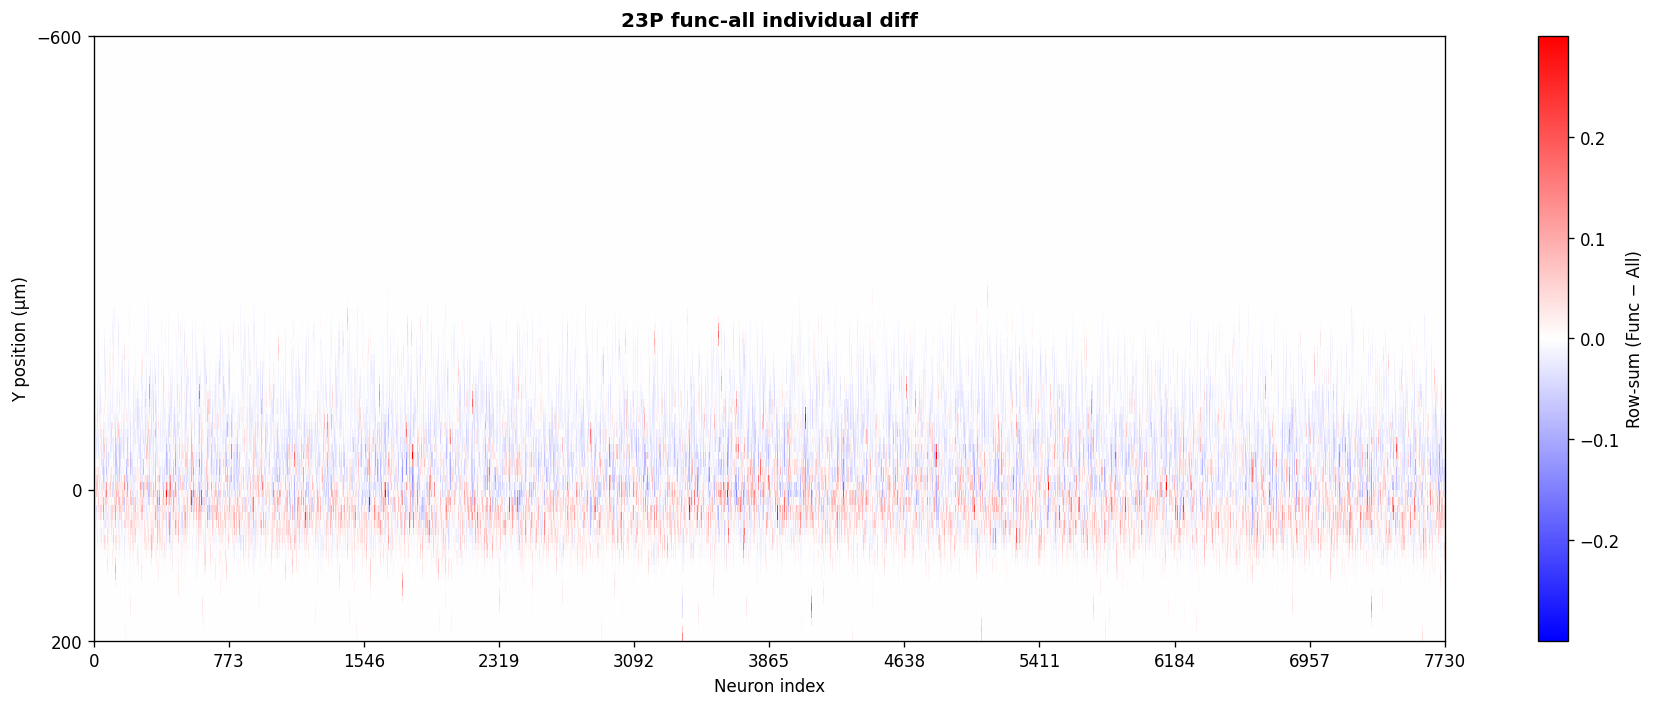

In [75]:
# M is (Ny, N_neurons)

M = row_sum_per_neuron.T
Ny, N_neurons = M.shape
y_min, y_max = y_edges[0], y_edges[-1]

fig, ax = plt.subplots(figsize=(14, 6), dpi=120)  # <- fixed size (no scaling by N)

im = ax.imshow(
    M,
    origin='lower',
    cmap='bwr',
    norm=TwoSlopeNorm(vmin=-0.3, vcenter=0.0, vmax=0.3),
    aspect='auto',
    extent=[0, N_neurons, y_min, y_max],
    interpolation='nearest',        # keeps it crisp without exploding pixels
)
ax.set_ylim(200, -600)
ax.set_xlabel('Neuron index')
ax.set_ylabel('Y position (µm)')
ax.set_yticks([200, 0, -600])

# sparse x ticks
step = max(1, N_neurons // 10)
ticks = np.arange(0, N_neurons + 1, step)
ax.set_xticks(ticks)
ax.set_xticklabels([str(t) for t in ticks])

cbar = fig.colorbar(im, ax=ax, fraction=0.06, pad=0.06)
cbar.set_label('Row-sum (Func − All)')
plt.title("23P func-all individual diff",fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


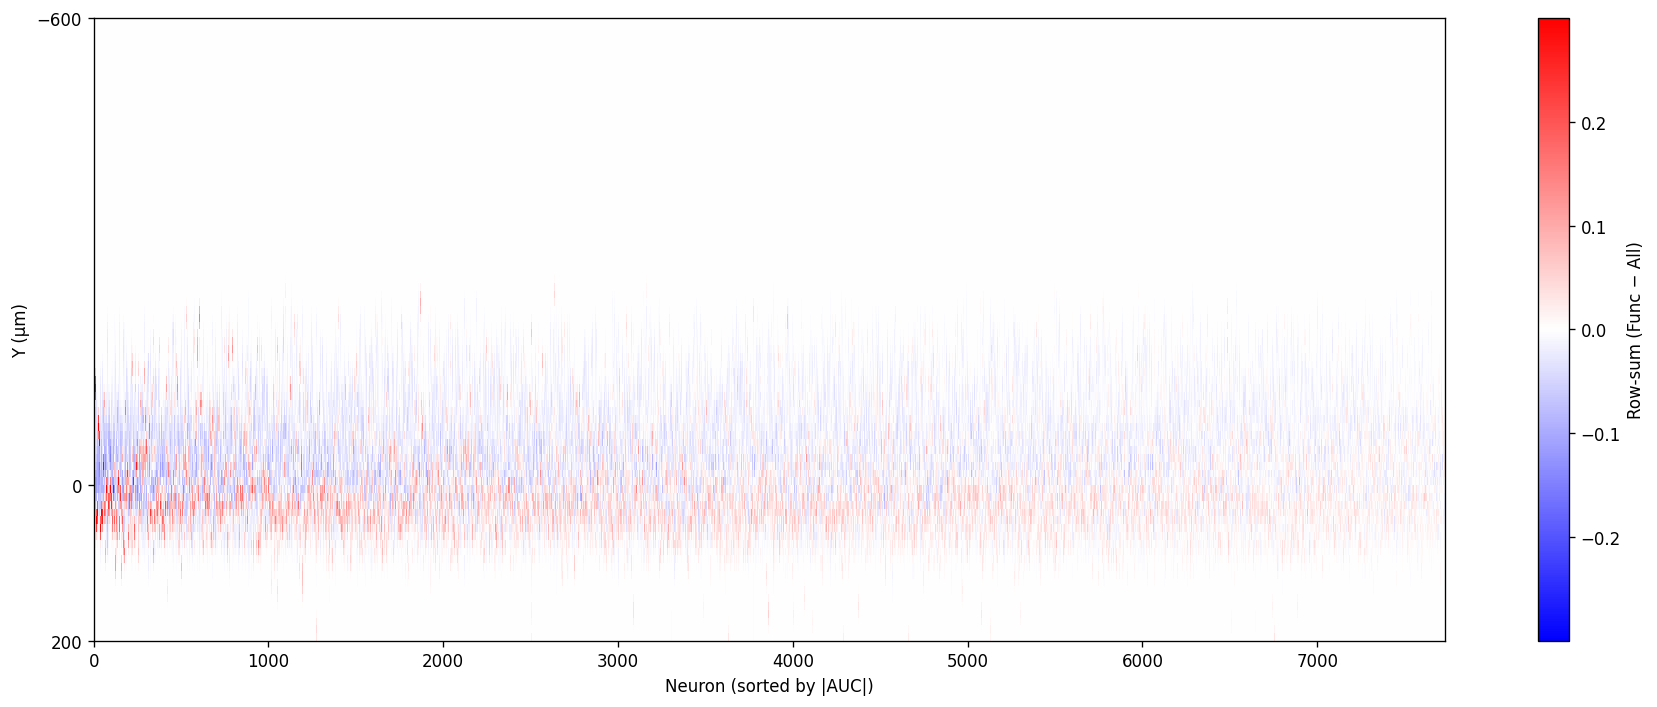

In [76]:
M = row_sum_per_neuron.T               # (Ny, N)
N = M.shape[1]
order = np.argsort(-np.abs(auc_abs_per_neuron))  # descending |AUC|
M_sorted = M[:, order]

y_min, y_max = y_edges[0], y_edges[-1]
fig, ax = plt.subplots(figsize=(14, 6), dpi=120)
im = ax.imshow(
    M_sorted, origin='lower', cmap='bwr',
    norm=TwoSlopeNorm(vmin=-0.3, vcenter=0.0, vmax=0.3),
    aspect='auto', extent=[0, N, y_min, y_max], interpolation='nearest'
)
ax.set_ylim(200, -600); ax.set_yticks([200, 0, -600])
ax.set_xlabel('Neuron (sorted by |AUC|)'); ax.set_ylabel('Y (µm)')
cbar = fig.colorbar(im, ax=ax, fraction=0.06, pad=0.06)
cbar.set_label('Row-sum (Func − All)')
plt.tight_layout(); plt.show()


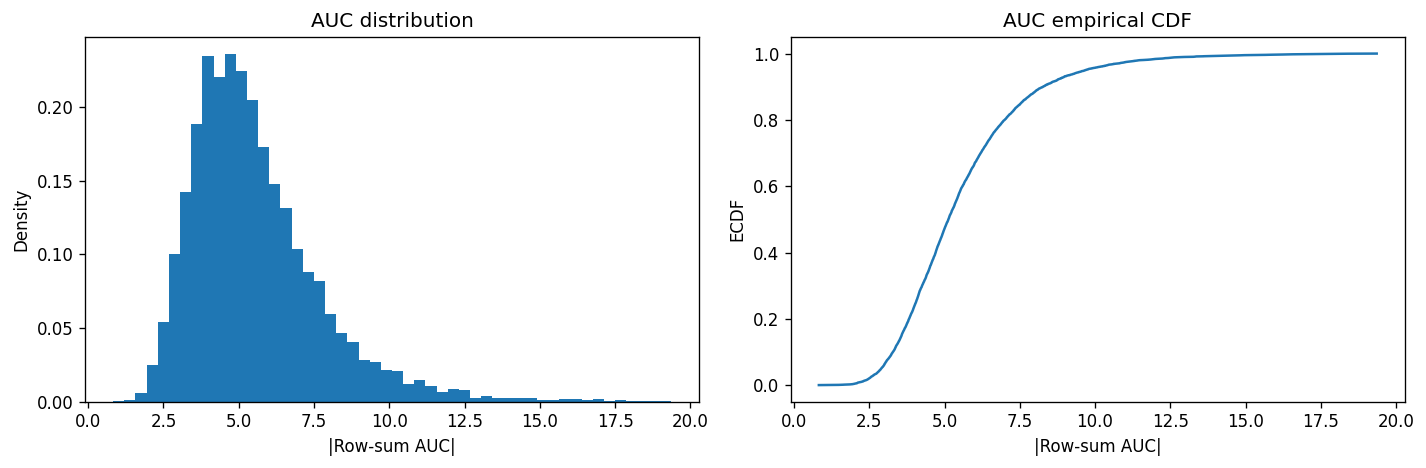

In [77]:
import numpy as np
import matplotlib.pyplot as plt

x = auc_abs_per_neuron
fig, axs = plt.subplots(1, 2, figsize=(12, 4), dpi=120)

# Histogram (density)
axs[0].hist(x, bins=50, density=True)
axs[0].set_xlabel('|Row-sum AUC|'); axs[0].set_ylabel('Density')
axs[0].set_title('AUC distribution')

# ECDF
xs = np.sort(x); ys = np.arange(1, len(x)+1)/len(x)
axs[1].plot(xs, ys)
axs[1].set_xlabel('|Row-sum AUC|'); axs[1].set_ylabel('ECDF')
axs[1].set_title('AUC empirical CDF')

plt.tight_layout(); plt.show()


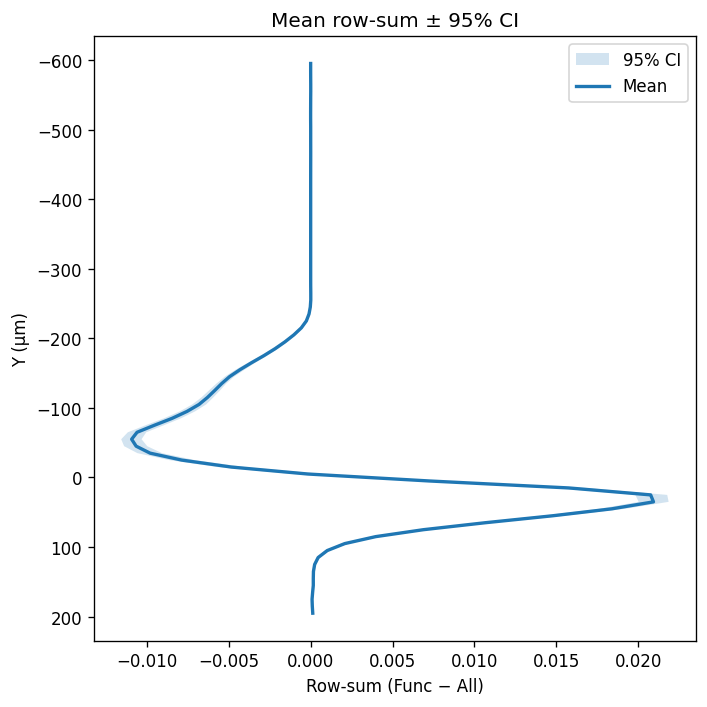

In [78]:
import numpy as np
import matplotlib.pyplot as plt

M = row_sum_per_neuron      # (N, Ny)
y_centers = 0.5*(y_edges[:-1] + y_edges[1:])
B = 1000  # bootstrap iters (tune as you like)

# bootstrap percentiles per y-bin
N, Ny = M.shape
boot_means = np.empty((B, Ny), dtype=float)
rng = np.random.default_rng(0)
for b in range(B):
    idx = rng.integers(0, N, size=N)
    boot_means[b] = M[idx].mean(axis=0)

lo = np.percentile(boot_means, 2.5, axis=0)
hi = np.percentile(boot_means, 97.5, axis=0)
mu = M.mean(axis=0)

plt.figure(figsize=(6,6), dpi=120)
plt.fill_betweenx(y_centers, lo, hi, alpha=0.2, label='95% CI')
plt.plot(mu, y_centers, label='Mean', linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel('Row-sum (Func − All)'); plt.ylabel('Y (µm)')
plt.title('Mean row-sum ± 95% CI'); plt.legend()
plt.tight_layout(); plt.show()


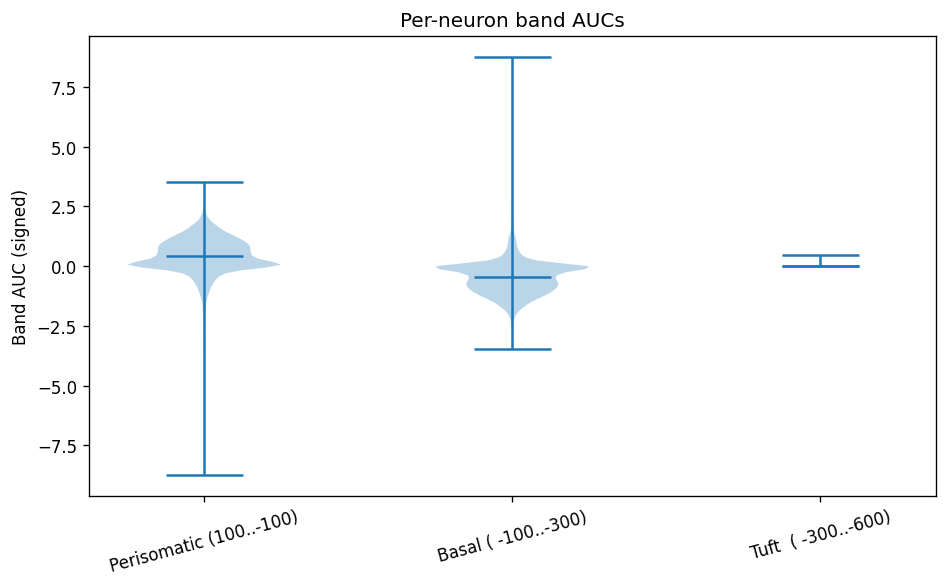

In [79]:
import numpy as np
import matplotlib.pyplot as plt

M = row_sum_per_neuron           # (N, Ny)
y_centers = 0.5*(y_edges[:-1] + y_edges[1:])
dy = np.diff(y_edges)

# define bands (edit as you prefer)
bands = {
    'Perisomatic (100..-100)': (y_centers <= 100) & (y_centers >= -100),
    'Basal ( -100..-300)':     (y_centers < -100) & (y_centers >= -300),
    'Tuft  ( -300..-600)':     (y_centers < -300) & (y_centers >= -600),
}

vals = []
labels = []
for name, mask in bands.items():
    # signed or absolute—choose one:
    auc_band = (M[:, mask] * dy[mask]).sum(axis=1)             # signed
    # auc_band = (np.abs(M[:, mask]) * dy[mask]).sum(axis=1)   # absolute
    vals.append(auc_band); labels.append(name)

plt.figure(figsize=(8,5), dpi=120)
plt.violinplot(vals, showmeans=True, showmedians=False)
plt.xticks(np.arange(1, len(labels)+1), labels, rotation=15)
plt.ylabel('Band AUC (signed)'); plt.title('Per-neuron band AUCs')
plt.tight_layout(); plt.show()


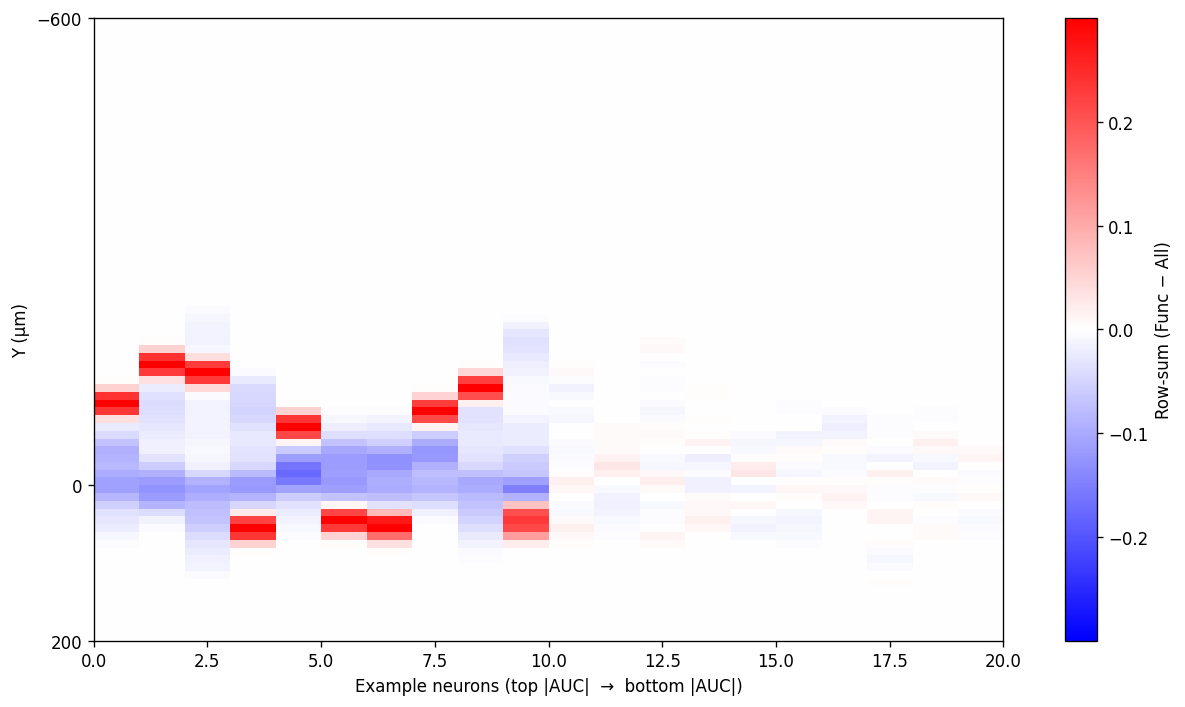

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

M = row_sum_per_neuron.T  # (Ny, N)
N = M.shape[1]
order = np.argsort(-np.abs(auc_abs_per_neuron))

k = 10  # how many from each end to show
cols = np.concatenate([order[:k], order[-k:]])
M_sel = M[:, cols]

y_min, y_max = y_edges[0], y_edges[-1]
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
im = ax.imshow(
    M_sel, origin='lower', cmap='bwr',
    norm=TwoSlopeNorm(vmin=-0.3, vcenter=0.0, vmax=0.3),
    aspect='auto', extent=[0, M_sel.shape[1], y_min, y_max], interpolation='nearest'
)
ax.set_ylim(200, -600); ax.set_yticks([200, 0, -600])
ax.set_xlabel('Example neurons (top |AUC|  →  bottom |AUC|)')
ax.set_ylabel('Y (µm)')
fig.colorbar(im, ax=ax, fraction=0.06, pad=0.06).set_label('Row-sum (Func − All)')
plt.tight_layout(); plt.show()


### 4P

In [97]:
# Calculate individual neuron's difference and calculate AUC

res_4P = accumulate_rowsum_diffs(
    neuron_list_4P,
    functional_properties_v3_bcm,
    nucleus_detection_v0,
    convert_to_nm,
    path_project="/media/DATA1/CK/python_script/MicronsBinder_04/data/data_raw/synapse/",
    bin_size_um=10,
    x_lim_um=(-200, 200),
    y_lim_um=(-600, 200),
    smooth_sigma=1,              
    take_abs_for_auc=True,       
    require_functional=True      
)

In [121]:
# Unpack what you need
row_sum_per_neuron = res_4P["row_sum_per_neuron"]   # shape: (N_contrib, Ny)
row_sum_mean       = res_4P["row_sum_mean"]         # shape: (Ny,)
auc_abs_per_neuron = res_4P["auc_abs_per_neuron"]   # shape: (N_contrib,)
auc_abs_mean       = res_4P["auc_abs_mean"]         # float
y_edges            = res_4P["y_edges"]              # shape: (Ny+1,)

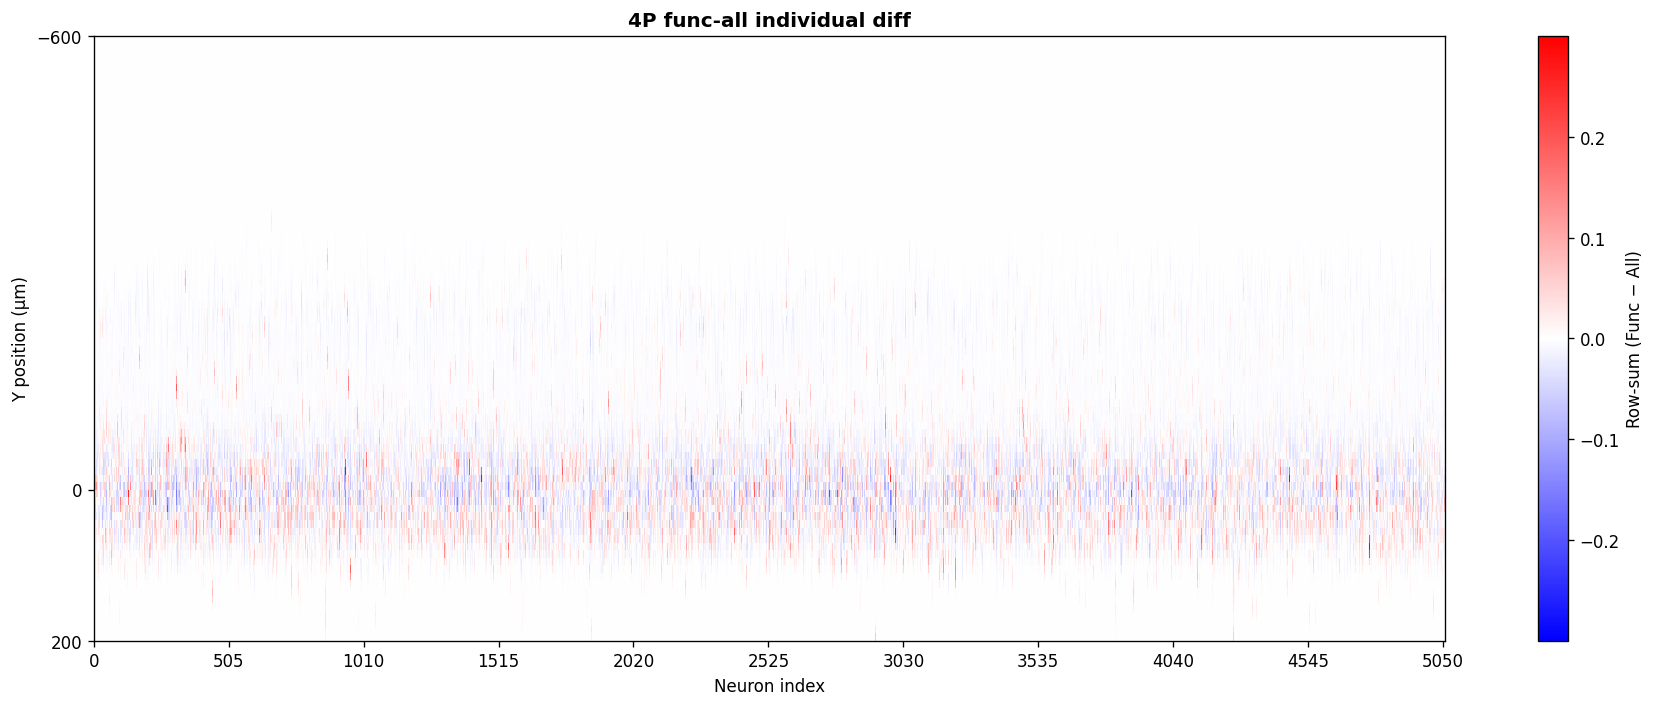

In [102]:
# M is (Ny, N_neurons)

M = row_sum_per_neuron.T
Ny, N_neurons = M.shape
y_min, y_max = y_edges[0], y_edges[-1]

fig, ax = plt.subplots(figsize=(14, 6), dpi=120)  # <- fixed size (no scaling by N)

im = ax.imshow(
    M,
    origin='lower',
    cmap='bwr',
    norm=TwoSlopeNorm(vmin=-0.3, vcenter=0.0, vmax=0.3),
    aspect='auto',
    extent=[0, N_neurons, y_min, y_max],
    interpolation='nearest',        # keeps it crisp without exploding pixels
)
ax.set_ylim(200, -600)
ax.set_xlabel('Neuron index')
ax.set_ylabel('Y position (µm)')
ax.set_yticks([200, 0, -600])

# sparse x ticks
step = max(1, N_neurons // 10)
ticks = np.arange(0, N_neurons + 1, step)
ax.set_xticks(ticks)
ax.set_xticklabels([str(t) for t in ticks])

cbar = fig.colorbar(im, ax=ax, fraction=0.06, pad=0.06)
cbar.set_label('Row-sum (Func − All)')
plt.title("4P func-all individual diff",fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


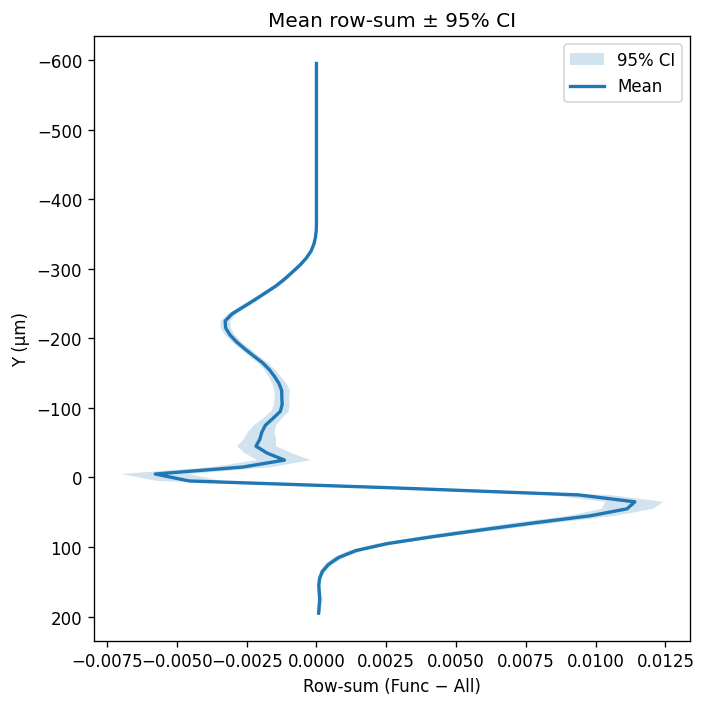

In [118]:
import numpy as np
import matplotlib.pyplot as plt

M = row_sum_per_neuron      # (N, Ny)
y_centers = 0.5*(y_edges[:-1] + y_edges[1:])
B = 1000  # bootstrap iters (tune as you like)

# bootstrap percentiles per y-bin
N, Ny = M.shape
boot_means = np.empty((B, Ny), dtype=float)
rng = np.random.default_rng(0)
for b in range(B):
    idx = rng.integers(0, N, size=N)
    boot_means[b] = M[idx].mean(axis=0)

lo = np.percentile(boot_means, 2.5, axis=0)
hi = np.percentile(boot_means, 97.5, axis=0)
mu = M.mean(axis=0)

plt.figure(figsize=(6,6), dpi=120)
plt.fill_betweenx(y_centers, lo, hi, alpha=0.2, label='95% CI')
plt.plot(mu, y_centers, label='Mean', linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel('Row-sum (Func − All)'); plt.ylabel('Y (µm)')
plt.title('Mean row-sum ± 95% CI'); plt.legend()
plt.tight_layout(); plt.show()


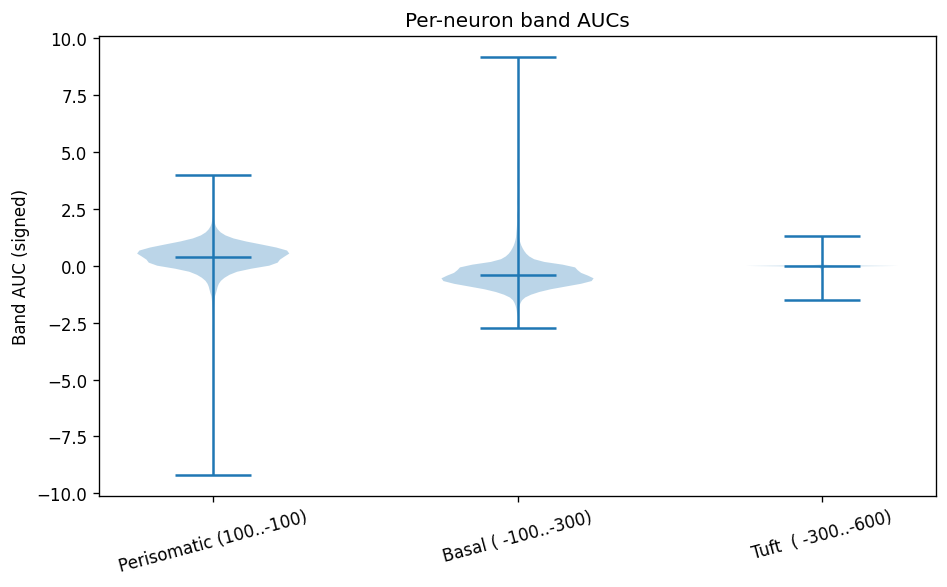

In [122]:
import numpy as np
import matplotlib.pyplot as plt

M = row_sum_per_neuron           # (N, Ny)
y_centers = 0.5*(y_edges[:-1] + y_edges[1:])
dy = np.diff(y_edges)

# define bands (edit as you prefer)
bands = {
    'Perisomatic (100..-100)': (y_centers <= 100) & (y_centers >= -100),
    'Basal ( -100..-300)':     (y_centers < -100) & (y_centers >= -300),
    'Tuft  ( -300..-600)':     (y_centers < -300) & (y_centers >= -600),
}

vals = []
labels = []
for name, mask in bands.items():
    # signed or absolute—choose one:
    auc_band = (M[:, mask] * dy[mask]).sum(axis=1)             # signed
    # auc_band = (np.abs(M[:, mask]) * dy[mask]).sum(axis=1)   # absolute
    vals.append(auc_band); labels.append(name)

plt.figure(figsize=(8,5), dpi=120)
plt.violinplot(vals, showmeans=True, showmedians=False)
plt.xticks(np.arange(1, len(labels)+1), labels, rotation=15)
plt.ylabel('Band AUC (signed)'); plt.title('Per-neuron band AUCs')
plt.tight_layout(); plt.show()


### 5P

In [98]:
# Calculate individual neuron's difference and calculate AUC

res_5P = accumulate_rowsum_diffs(
    neuron_list_5P,
    functional_properties_v3_bcm,
    nucleus_detection_v0,
    convert_to_nm,
    path_project="/media/DATA1/CK/python_script/MicronsBinder_04/data/data_raw/synapse/",
    bin_size_um=10,
    x_lim_um=(-200, 200),
    y_lim_um=(-600, 200),
    smooth_sigma=1,              
    take_abs_for_auc=True,       
    require_functional=True      
)

In [123]:
# Unpack what you need
row_sum_per_neuron = res_5P["row_sum_per_neuron"]   # shape: (N_contrib, Ny)
row_sum_mean       = res_5P["row_sum_mean"]         # shape: (Ny,)
auc_abs_per_neuron = res_5P["auc_abs_per_neuron"]   # shape: (N_contrib,)
auc_abs_mean       = res_5P["auc_abs_mean"]         # float
y_edges            = res_5P["y_edges"]              # shape: (Ny+1,)

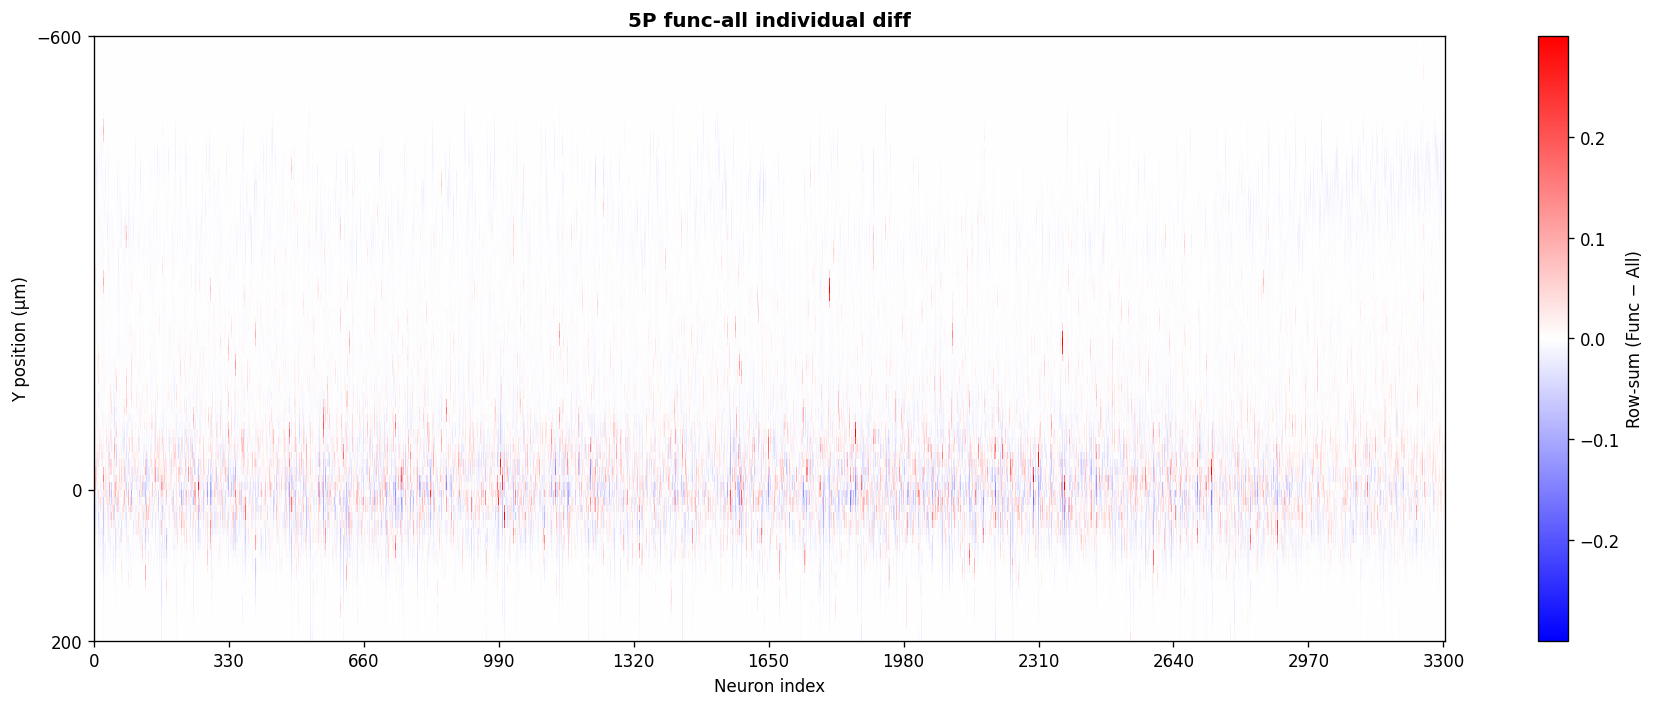

In [116]:
# M is (Ny, N_neurons)

M = row_sum_per_neuron.T
Ny, N_neurons = M.shape
y_min, y_max = y_edges[0], y_edges[-1]

fig, ax = plt.subplots(figsize=(14, 6), dpi=120)  # <- fixed size (no scaling by N)

im = ax.imshow(
    M,
    origin='lower',
    cmap='bwr',
    norm=TwoSlopeNorm(vmin=-0.3, vcenter=0.0, vmax=0.3),
    aspect='auto',
    extent=[0, N_neurons, y_min, y_max],
    interpolation='nearest',        # keeps it crisp without exploding pixels
)
ax.set_ylim(200, -600)
ax.set_xlabel('Neuron index')
ax.set_ylabel('Y position (µm)')
ax.set_yticks([200, 0, -600])

# sparse x ticks
step = max(1, N_neurons // 10)
ticks = np.arange(0, N_neurons + 1, step)
ax.set_xticks(ticks)
ax.set_xticklabels([str(t) for t in ticks])

cbar = fig.colorbar(im, ax=ax, fraction=0.06, pad=0.06)
cbar.set_label('Row-sum (Func − All)')
plt.title("5P func-all individual diff",fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


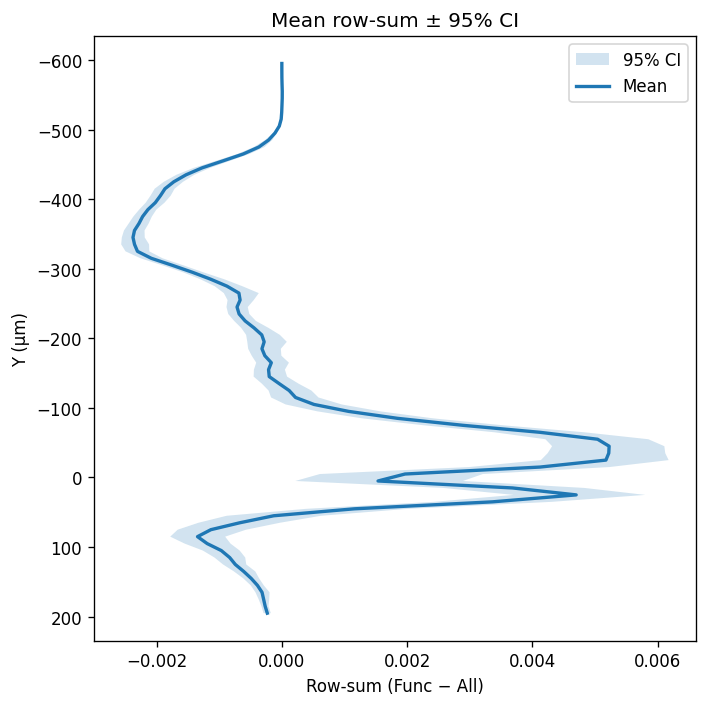

In [120]:
import numpy as np
import matplotlib.pyplot as plt

M = row_sum_per_neuron      # (N, Ny)
y_centers = 0.5*(y_edges[:-1] + y_edges[1:])
B = 1000  # bootstrap iters (tune as you like)

# bootstrap percentiles per y-bin
N, Ny = M.shape
boot_means = np.empty((B, Ny), dtype=float)
rng = np.random.default_rng(0)
for b in range(B):
    idx = rng.integers(0, N, size=N)
    boot_means[b] = M[idx].mean(axis=0)

lo = np.percentile(boot_means, 2.5, axis=0)
hi = np.percentile(boot_means, 97.5, axis=0)
mu = M.mean(axis=0)

plt.figure(figsize=(6,6), dpi=120)
plt.fill_betweenx(y_centers, lo, hi, alpha=0.2, label='95% CI')
plt.plot(mu, y_centers, label='Mean', linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel('Row-sum (Func − All)'); plt.ylabel('Y (µm)')
plt.title('Mean row-sum ± 95% CI'); plt.legend()
plt.tight_layout(); plt.show()


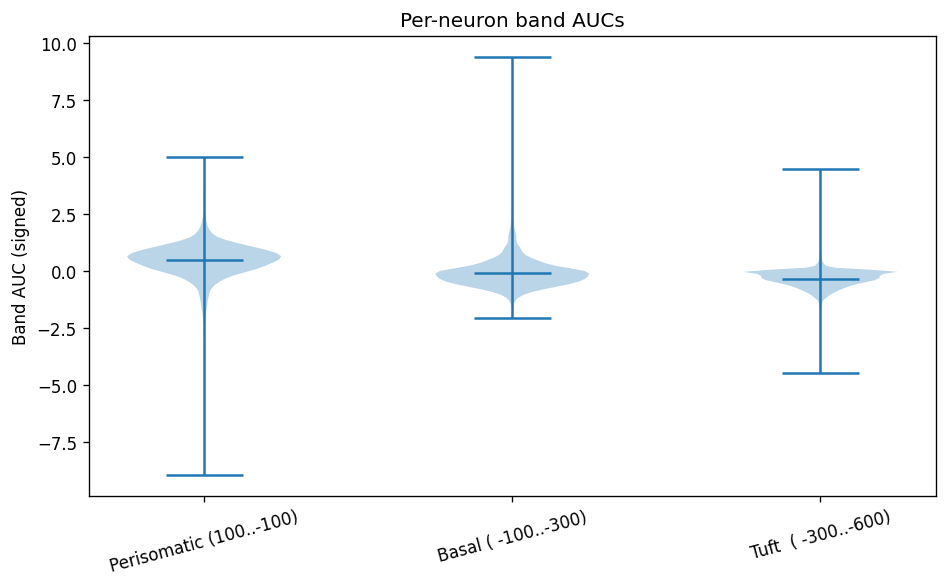

In [124]:
import numpy as np
import matplotlib.pyplot as plt

M = row_sum_per_neuron           # (N, Ny)
y_centers = 0.5*(y_edges[:-1] + y_edges[1:])
dy = np.diff(y_edges)

# define bands (edit as you prefer)
bands = {
    'Perisomatic (100..-100)': (y_centers <= 100) & (y_centers >= -100),
    'Basal ( -100..-300)':     (y_centers < -100) & (y_centers >= -300),
    'Tuft  ( -300..-600)':     (y_centers < -300) & (y_centers >= -600),
}

vals = []
labels = []
for name, mask in bands.items():
    # signed or absolute—choose one:
    auc_band = (M[:, mask] * dy[mask]).sum(axis=1)             # signed
    # auc_band = (np.abs(M[:, mask]) * dy[mask]).sum(axis=1)   # absolute
    vals.append(auc_band); labels.append(name)

plt.figure(figsize=(8,5), dpi=120)
plt.violinplot(vals, showmeans=True, showmedians=False)
plt.xticks(np.arange(1, len(labels)+1), labels, rotation=15)
plt.ylabel('Band AUC (signed)'); plt.title('Per-neuron band AUCs')
plt.tight_layout(); plt.show()


## BAD analysis with Apical and Basal

In [5]:
# ==== Read datacleaner units ====

cleaner = mic.MicronsDataCleaner(datadir = "data", version=1300)   #Target version and download folder
cleaner.download_nucleus_data()    #Download the data
units, segments = cleaner.process_nucleus_data() #Process the downloaded data and segment into layers

Transform positions: 100%|█████████████| 94014/94014 [00:01<00:00, 92439.56it/s]


In [23]:
# ==== Read preprocessed dataset with xab (axon apical basal) labeled ====

# # Choose layer # CHANGE HERE!!!!!!!
# post_layer_label = "L2/3"
# neuron_layer = "full_features_all_L23_neurons.csv"
# csv_path = os.path.join("/media/DATA1/CK/python_script/MicronsBinder_04/data/data_processed/neurons_23P_13305/", neuron_layer)

# post_layer_label = "L4"
# neuron_layer = "full_features_all_L4_neurons.csv"
# csv_path = os.path.join("/media/DATA1/CK/python_script/MicronsBinder_04/data/data_processed/neurons_4P_9940/", neuron_layer)

post_layer_label = "L5"
neuron_layer = "full_features_all_L5_neurons.csv"
csv_path = os.path.join("/media/DATA1/CK/python_script/MicronsBinder_04/data/data_processed/neurons_5P_7148/", neuron_layer)

# read
df = pd.read_csv(csv_path, low_memory=False)

# quick print
print("shape:", df.shape)
print("columns:", len(df.columns))
display(df.head())

shape: (8398951, 33)
columns: 33


,synapse_id,size,pre_pt_root_id,node_id,distance_from_soma,branch_order,dendrites,segments,type,post_pt_root_id,...,cc_abs_pre,pref_ori_post,pref_dir_post,gOSI_post,gDSI_post,cc_abs_post,pref_ori_diff_wrapped,pref_dir_diff_wrapped,strat_axon_pre,strat_dendrite_post
0,309395306,3164.0,864691135538129266,1452,86.327792,1,8,1,3.0,864691134885137402,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none,none
1,289161294,3632.0,864691135456102346,1572,38.228342,3,4,5,3.0,864691134885137402,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none
2,284849188,3200.0,864691135947139208,290,206.340992,5,2,10,4.0,864691134885137402,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none
3,292863493,2596.0,864691136634153334,1,10.996328,1,1,1,2.0,864691134885137402,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none
4,273012453,1480.0,864691135746546163,925,170.929374,5,3,8,3.0,864691134885137402,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none


In [24]:
# Now we have to add labels that specify where each synapse are coming from! (specify layer of inputs)
# Bring layer information from datacleaner as well as positions

# Add pre- and post- layer (and pre positions)
df_layer = df

# 1) Start from the units table: keep only what we need
cols_to_keep = ["pt_root_id", "cell_type", "layer", "pt_position_x", "pt_position_y", "pt_position_z"]
units_sub = units[cols_to_keep].drop_duplicates(subset="pt_root_id")

# 2) Build a "pre" lookup table
units_pre = units_sub.rename(columns={
    "pt_root_id":    "pre_pt_root_id",
    "cell_type":     "pre_cell_type",      # Add this to exclude inhibitory neurons
    "layer":         "pre_layer",
    "pt_position_x": "pre_pt_position_x",
    "pt_position_y": "pre_pt_position_y",
    "pt_position_z": "pre_pt_position_z",
})

# 3) Merge presyn info onto df_layer
df_layer = df_layer.merge(
    units_pre,
    how="left",
    on="pre_pt_root_id"
)

# 4) Build a "post" lookup table (only need layer, but you can add positions too)
units_post = units_sub[["pt_root_id", "layer"]].rename(columns={
    "pt_root_id": "post_pt_root_id",
    "layer":      "post_layer",
})

# 5) Merge postsyn info onto df_layer
df_layer = df_layer.merge(
    units_post,
    how="left",
    on="post_pt_root_id"
)

# 6) keep only excitatory presynaptic partners (pyramidal classes) ---

# Option A (robust): detect excitatory as pyramidal classes in MICrONS naming
# (matches: 23P, 4P, 5P-IT, 5P-ET, 5P-NP, 6P-IT, 6P-CT, etc.)
exc_mask = (
    df_layer["pre_cell_type"].notna()
    & df_layer["pre_cell_type"].astype(str).str.match(r"^(23P|[456]P)", na=False)
)

df_layer_exc = df_layer.loc[exc_mask].copy()

# Optional: also require that pre_layer exists (since you’re doing layer-based analysis)
df_layer_exc = df_layer_exc[df_layer_exc["pre_layer"].notna()].copy()

print("All presyn cell types:", df_layer["pre_cell_type"].dropna().unique())
print("Excitatory presyn cell types kept:", df_layer_exc["pre_cell_type"].unique())
print("Rows before:", len(df_layer), "after:", len(df_layer_exc))

All presyn cell types: ['4P' '5P-IT' '23P' 'astrocyte' 'NGC' 'MC' 'BC' 'oligo' '6P-IT' '5P-ET'
 'BPC' 'OPC' 'microglia' '6P-CT' '5P-NP' 'pericyte']
Excitatory presyn cell types kept: ['4P' '5P-IT' '23P' '6P-IT' '5P-ET' '6P-CT' '5P-NP']
Rows before: 8398951 after: 365771


In [25]:
df_layer_exc

,synapse_id,size,pre_pt_root_id,node_id,distance_from_soma,branch_order,dendrites,segments,type,post_pt_root_id,...,pref_ori_diff_wrapped,pref_dir_diff_wrapped,strat_axon_pre,strat_dendrite_post,pre_cell_type,pre_layer,pre_pt_position_x,pre_pt_position_y,pre_pt_position_z,post_layer
0,309395306,3164.0,864691135538129266,1452,86.327792,1,8,1,3.0,864691134885137402,...,NaN,NaN,none,none,4P,L5,934.134607,362.384599,808.92,L5
14,302794109,12532.0,864691135661211120,2254,116.784626,3,7,8,3.0,864691134885137402,...,NaN,NaN,none,none,5P-IT,L5,1038.868698,420.951642,776.76,L5
18,313950995,3576.0,864691135911069097,2130,77.441321,4,4,7,3.0,864691134885137402,...,NaN,NaN,none,none,23P,L2/3,800.663750,147.630644,1046.92,L5
21,292600256,1308.0,864691135968887909,991,11.989969,1,4,1,3.0,864691134885137402,...,NaN,NaN,none,none,5P-IT,L5,918.700977,380.179183,765.44,L5
38,309395638,11480.0,864691135776896429,1030,79.643139,6,4,10,3.0,864691134885137402,...,NaN,NaN,none,none,23P,L2/3,1004.270008,236.305533,731.64,L5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8398927,91912430,2324.0,864691134940963939,4029,22.517633,1,11,1,3.0,864691137198933569,...,NaN,NaN,none,none,23P,L2/3,520.828841,137.924490,735.96,L5
8398941,64227894,3224.0,864691135368081145,939,83.806050,5,3,12,4.0,864691137198933569,...,NaN,NaN,none,none,23P,L2/3,426.059285,239.362782,757.04,L5
8398943,79042267,9104.0,864691136952277215,3769,94.442190,4,1,7,3.0,864691137198933569,...,NaN,NaN,none,none,5P-ET,L5,457.647837,491.459209,723.08,L5
8398944,88983066,2552.0,864691136905147314,2135,20.154801,2,5,2,3.0,864691137198933569,...,NaN,NaN,none,none,4P,L4,416.341598,273.333097,765.56,L5


In [26]:
type_map = {3.0: "basal", 4.0: "apical"}

def counts_by_pre_post(df_layer_exc, type_map=type_map):
    df = df_layer_exc.loc[:, ["pre_layer", "post_layer", "type"]].copy()
    df["dend_type"] = pd.to_numeric(df["type"], errors="coerce").map(type_map)

    counts = (
        df.groupby(["post_layer", "pre_layer"])["dend_type"]
          .value_counts()
          .unstack(fill_value=0)
          .reindex(columns=["basal", "apical"], fill_value=0)
          .astype(int)
    )

    ratio = counts.assign(
        apical_to_basal=counts["apical"] / counts["basal"].replace(0, np.nan)
    )

    return counts, ratio

counts_all, ratio_all = counts_by_pre_post(df_layer_exc)

# Example: get the table just for one post layer
post_layer_label = post_layer_label
counts_df = counts_all.loc[post_layer_label]
ratio_df  = ratio_all.loc[post_layer_label]


In [27]:
counts_df

dend_type,basal,apical
pre_layer,,
L1,220,383
L2/3,48752,28991
L4,72907,45323
L5,70010,30181
L6,26133,12005


In [28]:
ratio_df

dend_type,basal,apical,apical_to_basal
pre_layer,,,
L1,220,383,1.740909
L2/3,48752,28991,0.594663
L4,72907,45323,0.621655
L5,70010,30181,0.431096
L6,26133,12005,0.459381


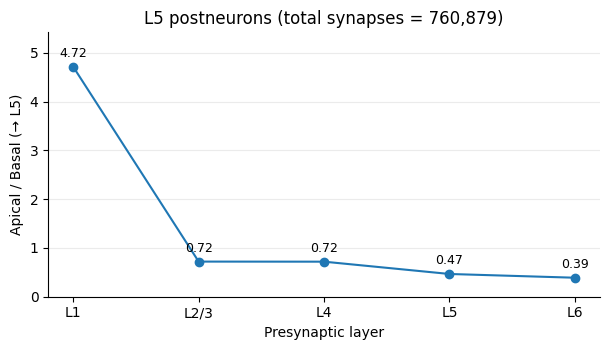

In [55]:
# =========================
# Plot 1) ALL pre layers present in ratio_df (e.g., L1–L6)
# =========================
post_layer_label = "L5"

# Define a canonical order, then keep only those that exist
layer_order_all = ["L1", "L2/3", "L4", "L5", "L6"]

ratio_plot = ratio_df.reindex(layer_order_all).dropna(subset=["apical_to_basal"], how="all")
vals = ratio_plot["apical_to_basal"].to_numpy()
labels = ratio_plot.index.to_list()
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(x, vals, marker="o", linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Presynaptic layer")
ax.set_ylabel(f"Apical / Basal (→ {post_layer_label})")

# y-limits + grid (safe if all NaN)
if np.isfinite(vals).any():
    ymax = np.nanmax(vals)
    ax.set_ylim(0, ymax * 1.15 if ymax > 0 else 1.0)
else:
    ymax = 1.0
    ax.set_ylim(0, 1.0)

ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# annotate points
for xi, v in zip(x, vals):
    if np.isfinite(v):
        ax.text(xi, v + max(ymax * 0.03, 0.03), f"{v:.2f}", ha="center", va="bottom", fontsize=9)

total_syn = int(counts_df.reindex(layer_order_all).fillna(0).values.sum())
ax.set_title(f"{post_layer_label} postneurons (total synapses = {total_syn:,})")

plt.tight_layout()
plt.show()


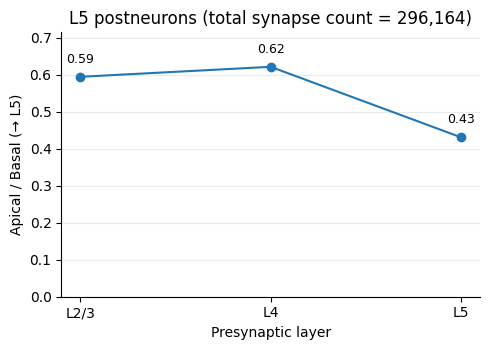

In [48]:
# =========================
# Plot 2) ONLY L2/3, L4, L5
# =========================
post_layer_label = post_layer_label

layer_order_subset = ["L2/3", "L4", "L5"]

ratio_plot = ratio_df.reindex(layer_order_subset)
vals = ratio_plot["apical_to_basal"].to_numpy()
labels = ratio_plot.index.to_list()
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(5.0, 3.6))
ax.plot(x, vals, marker="o", linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Presynaptic layer")
ax.set_ylabel(f"Apical / Basal (→ {post_layer_label})")

ymax = np.nanmax(vals) if np.isfinite(vals).any() else 1.0
ax.set_ylim(0, ymax * 1.15 if ymax > 0 else 1.0)

ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for xi, v in zip(x, vals):
    if np.isfinite(v):
        ax.text(xi, v + max(ymax * 0.03, 0.03), f"{v:.2f}",
                ha="center", va="bottom", fontsize=9)

# total synapses in these layers (basal+apical)
counts_subset = counts_df.reindex(layer_order_subset).fillna(0)
total_syn = int(counts_subset[["basal", "apical"]].to_numpy().sum())

ax.set_title(f"{post_layer_label} postneurons (total synapse count = {total_syn:,})")

plt.tight_layout()
plt.show()


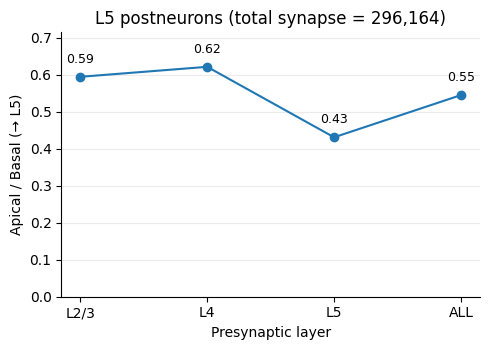

In [29]:
# =========================
# Plot 2) ONLY L2/3, L4, L5 + ALL
# =========================

layer_order_subset = ["L2/3", "L4", "L5"]

# --- compute ALL from counts (so it matches pooled counts) ---
counts_sub = counts_df.reindex(layer_order_subset).fillna(0)
basal_all  = counts_sub["basal"].sum()
apical_all = counts_sub["apical"].sum()
ratio_all  = apical_all / (basal_all if basal_all != 0 else np.nan)

# --- build plotting series ---
ratio_plot = ratio_df.reindex(layer_order_subset).copy()
ratio_plot.loc["ALL", "apical_to_basal"] = ratio_all

labels = layer_order_subset + ["ALL"]
vals = ratio_plot.loc[labels, "apical_to_basal"].to_numpy()
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(5.0, 3.6))
ax.plot(x, vals, marker="o", linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Presynaptic layer")
ax.set_ylabel(f"Apical / Basal (→ {post_layer_label})")

ymax = np.nanmax(vals) if np.isfinite(vals).any() else 1.0
ax.set_ylim(0, ymax * 1.15 if ymax > 0 else 1.0)

ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for xi, v in zip(x, vals):
    if np.isfinite(v):
        ax.text(xi, v + max(ymax * 0.03, 0.03), f"{v:.2f}",
                ha="center", va="bottom", fontsize=9)

# total synapses in these layers only (basal+apical)
total_syn = int(counts_sub[["basal", "apical"]].to_numpy().sum())

ax.set_title(f"{post_layer_label} postneurons (total synapse = {total_syn:,})")

plt.tight_layout()
plt.show()
